(0.0, 4.0)

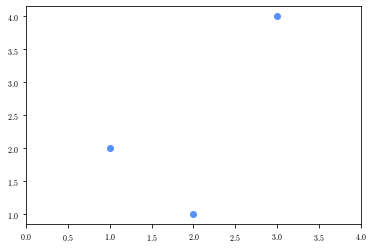

In [1]:
import matplotlib.pyplot as plt

plt.scatter([1, 2, 3], [2, 1, 4])
plt.xlim(0, 4)

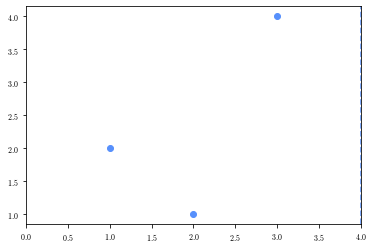

In [2]:
import matplotlib.pyplot as plt

plt.scatter([1, 2, 3], [2, 1, 4])
plt.xlim(0, 4)
plt.axvline(4, ls="--")

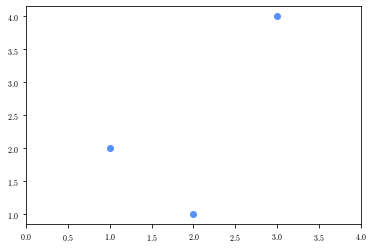

In [3]:
import matplotlib.pyplot as plt

plt.scatter([1, 2, 3], [2, 1, 4])
plt.xlim(0, 4)
plt.axvline(4.01, ls="--")

In [4]:
x = np.array([0, 1, 2, 3])

NameError: name 'np' is not defined

In [5]:
import numpy as np

In [6]:
x = np.array([0, 1, 2, 3])

In [7]:
x

array([0, 1, 2, 3])

In [8]:
np.histogram(x, range=(4, 10), bins=100)

(array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 array([ 4.  ,  4.06,  4.12,  4.18,  4.24,  4.3 ,  4.36,  4.42,  4.48,
         4.54,  4.6 ,  4.66,  4.72,  4.78,  4.84,  4.9 ,  4.96,  5.02,
         5.08,  5.14,  5.2 ,  5.26,  5.32,  5.38,  5.44,  5.5 ,  5.56,
         5.62,  5.68,  5.74,  5.8 ,  5.86,  5.92,  5.98,  6.04,  6.1 ,
         6.16,  6.22,  6.28,  6.34,  6.4 ,  6.46,  6.52,  6.58,  6.64,
         6.7 ,  6.76,  6.82,  6.88,  6.94,  7.  ,  7.06,  7.12,  7.18,
         7.24,  7.3 ,  7.36,  7.42,  7.48,  7.54,  7.6 ,  7.66,  7.72,
         7.78,  7.84,  7.9 ,  7.96,  8.02,  8.08,  8.14,  8.2 ,  8.26,
         8.32,  8.38,  8.44,  8.5 ,  8.56,  8.62,  8.68,  8.74,  8.8 ,
         8.86,  8.9

In [9]:
np.histogram(x, range=(4, 10), bins=100, density=True)

/astro/store/epyc/users/jfc20/local/mambaforge/envs/rubin-lya/lib/python3.9/site-packages/numpy/lib/histograms.py:906: RuntimeWarning: invalid value encountered in true_divide
  return n/db/n.sum(), bin_edges


(array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, nan, nan, nan, nan, nan]),
 array([ 4.  ,  4.06,  4.12,  4.18,  4.24,  4.3 ,  4.36,  4.42,  4.48,
         4.54,  4.6 ,  4.66,  4.72,  4.78,  4.84,  4.9 ,  4.96,  5.02,
         5.08,  5.14,  5.2 ,  5.26,  5.32,  5.38,  5.44,  5.5 ,  5.56,
         5.62,  5.68,  5.74,  5.8 ,  5.86,  5.92,  5.98,  6.04,  6.1 ,
         6.16,  6.22,  6.28,  6.34,  6.4 ,  6.46,  6.52,  6.58,  6.64,
         6.7 ,  6.76,  6.82,  6.88,  6.94,  7.  ,  7.06,  7.12,  7.18,
        

In [10]:
import pickle

import numpy as np
import pandas as pd
from pzflow import FlowEnsemble
from showyourwork.paths import user as Paths
from utils import sample_with_errors

# instantiate the paths
paths = Paths()

# load the flow ensembles
model_dir = paths.data / "models"
flow_ensembles = {
    "lsst": FlowEnsemble(file=model_dir / "lsst_ensemble.pzflow.pkl"),
    "lsst+euclid": FlowEnsemble(file=model_dir / "lsst+euclid_ensemble.pzflow.pkl"),
    "lsst+roman": FlowEnsemble(file=model_dir / "lsst+roman_ensemble.pzflow.pkl"),
    "perfect": FlowEnsemble(file=model_dir / "lsst+roman_ensemble.pzflow.pkl"),
}

# directory where the background catalogs are saved
bg_dir = paths.data / "background_catalogs"

# setup the grid of Delta u's on which to plot the likelihoods
deltas = np.linspace(-2, 3, 1000)

In [11]:
# and a dictionary to store the likelihoods
likelihood_dict = {}

# loop over the background catalogs
for file in bg_dir.glob("*.pkl"):
    stem = str(file.stem).removesuffix("_bg")
    print("calculating likelihoods for", stem)

    # load the catalog
    catalog = pd.read_pickle(file)

    # select the correct flow ensemble
    if "euclid" in stem:
        name = "euclid"
        ensemble = flow_ensembles["lsst+euclid"]
    elif "roman" in stem:
        name = "roman"
        ensemble = flow_ensembles["lsst+roman"]
    elif "perfect" in stem:
        name = "perfect"
        ensemble = flow_ensembles["perfect"]
    else:
        name = int(stem[5:])  # type: ignore
        ensemble = flow_ensembles["lsst"]

    if name != "perfect":
        continue

    # loop over batches
    likelihoods = []
    batch_size = 100
    for idx in range(0, len(catalog), batch_size):
        # get the batch
        batch = catalog[idx : idx + batch_size]

        if name == "perfect":
            # for the perfect catalog, we will draw a ton more samples and
            # build a histogram
            z_samples, u_samples = [], []
            for i in range(1):
                # draw this round of samples
                samples = sample_with_errors(batch, ensemble, i)

                # append them to the lists
                z_samples.append(samples[0])
                u_samples.append(samples[1])

            # combine the samples
            z_samples = np.hstack(z_samples)  # type: ignore
            u_samples = np.hstack(u_samples)  # type: ignore

            # flag the bad samples
            u_samples[z_samples < 2.36] = np.nan  # type: ignore

            # calculate Delta u from the samples of u and the true u
            delta_samples = u_samples - batch.u.to_numpy()[:, None]

            # create the histogram likelihoods
            diff = deltas[1] - deltas[0]
            bins = np.linspace(
                deltas.min() - diff, deltas.max() + diff, len(deltas) + 1
            )
            Ldu = [
                np.histogram(samples, bins, density=True)[0]
                for samples in delta_samples
            ]
            Ldu = np.array(Ldu)
            break

        else:
            # draw redshift samples
            z_samples, u_samples = sample_with_errors(batch, ensemble, seed=idx)  # type: ignore

            # flag the bad samples
            u_samples[z_samples < 2.36] = np.nan

            # add the grid of deltas
            u_alpha = u_samples[:, None, :] + deltas[None, :, None]

            # convert to flux
            u_alpha = 10 ** (u_alpha / -2.5)
            u_alpha_hat = 10 ** (batch.u.to_numpy() / -2.5)
            u_alpha_err = u_alpha_hat * (10 ** (batch.u_err.to_numpy() / -2.5) - 1)

            # calculate the likelihoods
            Ldu = np.exp(
                -((u_alpha - u_alpha_hat[:, None, None]) ** 2)
                / (2 * u_alpha_err[:, None, None] ** 2)
            ) / np.sqrt(2 * np.pi * u_alpha_err[:, None, None] ** 2)
            Ldu = np.nanmean(Ldu, axis=2)

            # normalize
            norms = np.trapz(Ldu, deltas)
            norms[norms > 0] = 1 / norms[norms > 0]
            norms[norms <= 0] = 0
            Ldu = norms[:, None] * Ldu

        # add to the list!
        likelihoods.append(Ldu)

    likelihoods = np.vstack(likelihoods)  # type: ignore
    likelihood_dict[name] = likelihoods

calculating likelihoods for lsstY10
calculating likelihoods for lsstY10+euclid
calculating likelihoods for lsstY10+roman
calculating likelihoods for lsstY1
calculating likelihoods for lsstY5
calculating likelihoods for perfect


ValueError: need at least one array to concatenate

In [12]:
# and a dictionary to store the likelihoods
likelihood_dict = {}

# loop over the background catalogs
for file in bg_dir.glob("*.pkl"):
    stem = str(file.stem).removesuffix("_bg")
    print("calculating likelihoods for", stem)

    # load the catalog
    catalog = pd.read_pickle(file)

    # select the correct flow ensemble
    if "euclid" in stem:
        name = "euclid"
        ensemble = flow_ensembles["lsst+euclid"]
    elif "roman" in stem:
        name = "roman"
        ensemble = flow_ensembles["lsst+roman"]
    elif "perfect" in stem:
        name = "perfect"
        ensemble = flow_ensembles["perfect"]
    else:
        name = int(stem[5:])  # type: ignore
        ensemble = flow_ensembles["lsst"]

    if name != "perfect":
        continue

    # loop over batches
    likelihoods = []
    batch_size = 100
    for idx in range(0, len(catalog), batch_size):
        # get the batch
        batch = catalog[idx : idx + batch_size]

        if name == "perfect":
            # for the perfect catalog, we will draw a ton more samples and
            # build a histogram
            z_samples, u_samples = [], []
            for i in range(1):
                # draw this round of samples
                samples = sample_with_errors(batch, ensemble, i)

                # append them to the lists
                z_samples.append(samples[0])
                u_samples.append(samples[1])

            # combine the samples
            z_samples = np.hstack(z_samples)  # type: ignore
            u_samples = np.hstack(u_samples)  # type: ignore

            # flag the bad samples
            u_samples[z_samples < 2.36] = np.nan  # type: ignore

            # calculate Delta u from the samples of u and the true u
            delta_samples = u_samples - batch.u.to_numpy()[:, None]

            # create the histogram likelihoods
            diff = deltas[1] - deltas[0]
            bins = np.linspace(
                deltas.min() - diff, deltas.max() + diff, len(deltas) + 1
            )
            Ldu = [
                np.histogram(samples, bins, density=True)[0]
                for samples in delta_samples
            ]
            Ldu = np.array(Ldu)

        else:
            # draw redshift samples
            z_samples, u_samples = sample_with_errors(batch, ensemble, seed=idx)  # type: ignore

            # flag the bad samples
            u_samples[z_samples < 2.36] = np.nan

            # add the grid of deltas
            u_alpha = u_samples[:, None, :] + deltas[None, :, None]

            # convert to flux
            u_alpha = 10 ** (u_alpha / -2.5)
            u_alpha_hat = 10 ** (batch.u.to_numpy() / -2.5)
            u_alpha_err = u_alpha_hat * (10 ** (batch.u_err.to_numpy() / -2.5) - 1)

            # calculate the likelihoods
            Ldu = np.exp(
                -((u_alpha - u_alpha_hat[:, None, None]) ** 2)
                / (2 * u_alpha_err[:, None, None] ** 2)
            ) / np.sqrt(2 * np.pi * u_alpha_err[:, None, None] ** 2)
            Ldu = np.nanmean(Ldu, axis=2)

            # normalize
            norms = np.trapz(Ldu, deltas)
            norms[norms > 0] = 1 / norms[norms > 0]
            norms[norms <= 0] = 0
            Ldu = norms[:, None] * Ldu

        # add to the list!
        likelihoods.append(Ldu)
        break

    likelihoods = np.vstack(likelihoods)  # type: ignore
    likelihood_dict[name] = likelihoods

calculating likelihoods for lsstY10
calculating likelihoods for lsstY10+euclid
calculating likelihoods for lsstY10+roman
calculating likelihoods for lsstY1
calculating likelihoods for lsstY5
calculating likelihoods for perfect


In [13]:
L = likelihood_dict["perfect"]

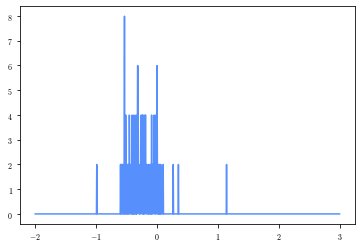

In [14]:
plt.plot(deltas, L[0])

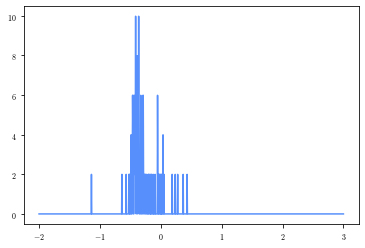

In [15]:
plt.plot(deltas, L[1])

In [16]:
# and a dictionary to store the likelihoods
likelihood_dict = {}

# loop over the background catalogs
for file in bg_dir.glob("*.pkl"):
    stem = str(file.stem).removesuffix("_bg")
    print("calculating likelihoods for", stem)

    # load the catalog
    catalog = pd.read_pickle(file)

    # select the correct flow ensemble
    if "euclid" in stem:
        name = "euclid"
        ensemble = flow_ensembles["lsst+euclid"]
    elif "roman" in stem:
        name = "roman"
        ensemble = flow_ensembles["lsst+roman"]
    elif "perfect" in stem:
        name = "perfect"
        ensemble = flow_ensembles["perfect"]
    else:
        name = int(stem[5:])  # type: ignore
        ensemble = flow_ensembles["lsst"]

    if name != "perfect":
        continue

    # loop over batches
    likelihoods = []
    batch_size = 100
    for idx in range(0, len(catalog), batch_size):
        # get the batch
        batch = catalog[idx : idx + batch_size]

        if name == "perfect":
            # for the perfect catalog, we will draw a ton more samples and
            # build a histogram
            z_samples, u_samples = [], []
            for i in range(100):
                # draw this round of samples
                samples = sample_with_errors(batch, ensemble, i)

                # append them to the lists
                z_samples.append(samples[0])
                u_samples.append(samples[1])

            # combine the samples
            z_samples = np.hstack(z_samples)  # type: ignore
            u_samples = np.hstack(u_samples)  # type: ignore

            # flag the bad samples
            u_samples[z_samples < 2.36] = np.nan  # type: ignore

            # calculate Delta u from the samples of u and the true u
            delta_samples = u_samples - batch.u.to_numpy()[:, None]

            # create the histogram likelihoods
            diff = deltas[1] - deltas[0]
            bins = np.linspace(
                deltas.min() - diff, deltas.max() + diff, len(deltas) + 1
            )
            Ldu = [
                np.histogram(samples, bins, density=True)[0]
                for samples in delta_samples
            ]
            Ldu = np.array(Ldu)

        else:
            # draw redshift samples
            z_samples, u_samples = sample_with_errors(batch, ensemble, seed=idx)  # type: ignore

            # flag the bad samples
            u_samples[z_samples < 2.36] = np.nan

            # add the grid of deltas
            u_alpha = u_samples[:, None, :] + deltas[None, :, None]

            # convert to flux
            u_alpha = 10 ** (u_alpha / -2.5)
            u_alpha_hat = 10 ** (batch.u.to_numpy() / -2.5)
            u_alpha_err = u_alpha_hat * (10 ** (batch.u_err.to_numpy() / -2.5) - 1)

            # calculate the likelihoods
            Ldu = np.exp(
                -((u_alpha - u_alpha_hat[:, None, None]) ** 2)
                / (2 * u_alpha_err[:, None, None] ** 2)
            ) / np.sqrt(2 * np.pi * u_alpha_err[:, None, None] ** 2)
            Ldu = np.nanmean(Ldu, axis=2)

            # normalize
            norms = np.trapz(Ldu, deltas)
            norms[norms > 0] = 1 / norms[norms > 0]
            norms[norms <= 0] = 0
            Ldu = norms[:, None] * Ldu

        # add to the list!
        likelihoods.append(Ldu)
        break

    likelihoods = np.vstack(likelihoods)  # type: ignore
    likelihood_dict[name] = likelihoods

calculating likelihoods for lsstY10
calculating likelihoods for lsstY10+euclid
calculating likelihoods for lsstY10+roman
calculating likelihoods for lsstY1
calculating likelihoods for lsstY5
calculating likelihoods for perfect


In [17]:
L = likelihood_dict["perfect"]

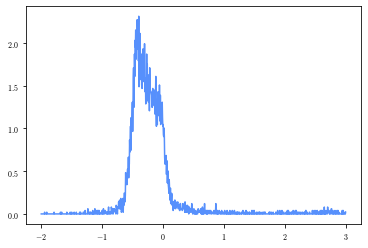

In [18]:
plt.plot(deltas, L[0])

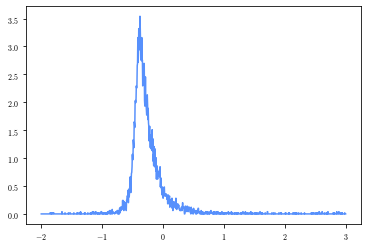

In [19]:
plt.plot(deltas, L[1])

In [20]:
# and a dictionary to store the likelihoods
likelihood_dict = {}

# loop over the background catalogs
for file in bg_dir.glob("*.pkl"):
    stem = str(file.stem).removesuffix("_bg")
    print("calculating likelihoods for", stem)

    # load the catalog
    catalog = pd.read_pickle(file)

    # select the correct flow ensemble
    if "euclid" in stem:
        name = "euclid"
        ensemble = flow_ensembles["lsst+euclid"]
    elif "roman" in stem:
        name = "roman"
        ensemble = flow_ensembles["lsst+roman"]
    elif "perfect" in stem:
        name = "perfect"
        ensemble = flow_ensembles["perfect"]
    else:
        name = int(stem[5:])  # type: ignore
        ensemble = flow_ensembles["lsst"]

    if name != "perfect":
        continue

    # loop over batches
    likelihoods = []
    batch_size = 100
    for idx in range(0, len(catalog), batch_size):
        # get the batch
        batch = catalog[idx : idx + batch_size]

        if name == "perfect":
            # for the perfect catalog, we will draw a ton more samples and
            # build a histogram
            z_samples, u_samples = [], []
            for i in range(10):
                # draw this round of samples
                samples = sample_with_errors(batch, ensemble, i)

                # append them to the lists
                z_samples.append(samples[0])
                u_samples.append(samples[1])

            # combine the samples
            z_samples = np.hstack(z_samples)  # type: ignore
            u_samples = np.hstack(u_samples)  # type: ignore

            # flag the bad samples
            u_samples[z_samples < 2.36] = np.nan  # type: ignore

            # calculate Delta u from the samples of u and the true u
            delta_samples = u_samples - batch.u.to_numpy()[:, None]

            # create the histogram likelihoods
            diff = deltas[1] - deltas[0]
            bins = np.linspace(
                deltas.min() - diff, deltas.max() + diff, len(deltas) + 1
            )
            Ldu = [
                np.histogram(samples, bins, density=True)[0]
                for samples in delta_samples
            ]
            Ldu = np.array(Ldu)

        else:
            # draw redshift samples
            z_samples, u_samples = sample_with_errors(batch, ensemble, seed=idx)  # type: ignore

            # flag the bad samples
            u_samples[z_samples < 2.36] = np.nan

            # add the grid of deltas
            u_alpha = u_samples[:, None, :] + deltas[None, :, None]

            # convert to flux
            u_alpha = 10 ** (u_alpha / -2.5)
            u_alpha_hat = 10 ** (batch.u.to_numpy() / -2.5)
            u_alpha_err = u_alpha_hat * (10 ** (batch.u_err.to_numpy() / -2.5) - 1)

            # calculate the likelihoods
            Ldu = np.exp(
                -((u_alpha - u_alpha_hat[:, None, None]) ** 2)
                / (2 * u_alpha_err[:, None, None] ** 2)
            ) / np.sqrt(2 * np.pi * u_alpha_err[:, None, None] ** 2)
            Ldu = np.nanmean(Ldu, axis=2)

            # normalize
            norms = np.trapz(Ldu, deltas)
            norms[norms > 0] = 1 / norms[norms > 0]
            norms[norms <= 0] = 0
            Ldu = norms[:, None] * Ldu

        # add to the list!
        likelihoods.append(Ldu)
        break

    likelihoods = np.vstack(likelihoods)  # type: ignore
    likelihood_dict[name] = likelihoods

calculating likelihoods for lsstY10
calculating likelihoods for lsstY10+euclid
calculating likelihoods for lsstY10+roman
calculating likelihoods for lsstY1
calculating likelihoods for lsstY5
calculating likelihoods for perfect


In [21]:
L = likelihood_dict["perfect"]

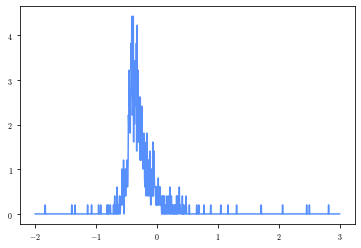

In [22]:
plt.plot(deltas, L[1])

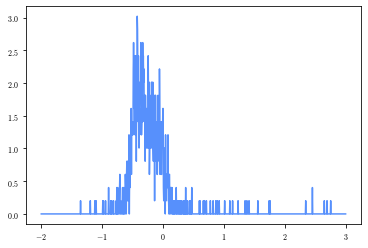

In [23]:
plt.plot(deltas, L[0])

In [24]:
catalog

,redshift,u,g,r,i,z,y,Y,J,H,...,u_err,g_err,r_err,i_err,z_err,y_err,Y_err,J_err,H_err,F_err
7,3.429946,33.079677,27.521906,26.608847,26.586004,26.781363,26.874483,26.858116,26.686022,26.487396,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
16,3.258337,31.745455,26.851946,26.128769,26.198679,26.484606,26.534178,26.468658,26.393900,26.236490,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
20,2.754195,27.684918,26.110250,25.969150,26.174213,26.261133,26.234276,26.234867,26.241310,25.875393,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
24,3.297755,32.077649,26.709707,25.375500,25.307333,25.483479,25.546642,25.453540,25.167492,24.757399,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
31,2.760499,27.063458,25.688880,25.470388,25.527096,25.570541,25.536112,25.488290,25.306063,24.579845,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
673903,2.963941,29.735989,26.811453,26.044579,26.097435,26.325663,26.142805,25.997547,25.613428,24.887207,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
673905,2.515746,27.468727,26.743420,26.764404,26.900310,26.945524,26.956554,26.962025,26.859968,26.404448,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
673909,2.584961,27.037165,24.932465,24.345800,24.375216,24.294971,24.125269,23.984755,23.560190,22.643553,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
673917,2.996105,32.703675,27.528648,24.869066,24.152256,23.935555,23.938034,23.768390,23.052570,22.059120,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [25]:
len(catalog) / 100

1107.23

In [26]:
# and a dictionary to store the likelihoods
likelihood_dict = {}

# loop over the background catalogs
for file in bg_dir.glob("*.pkl"):
    stem = str(file.stem).removesuffix("_bg")
    print("calculating likelihoods for", stem)

    # load the catalog
    catalog = pd.read_pickle(file)

    # select the correct flow ensemble
    if "euclid" in stem:
        name = "euclid"
        ensemble = flow_ensembles["lsst+euclid"]
    elif "roman" in stem:
        name = "roman"
        ensemble = flow_ensembles["lsst+roman"]
    elif "perfect" in stem:
        name = "perfect"
        ensemble = flow_ensembles["perfect"]
    else:
        name = int(stem[5:])  # type: ignore
        ensemble = flow_ensembles["lsst"]

    if name != "perfect":
        continue

    # loop over batches
    likelihoods = []
    batch_size = 100
    for idx in range(0, len(catalog), batch_size):
        # get the batch
        batch = catalog[idx : idx + batch_size]

        if name == "perfect":
            # for the perfect catalog, we will draw a ton more samples and
            # build a histogram
            z_samples, u_samples = sample_with_errors(batch, ensemble, 10_000, seed=idx)

            # flag the bad samples
            u_samples[z_samples < 2.36] = np.nan  # type: ignore

            # calculate Delta u from the samples of u and the true u
            delta_samples = u_samples - batch.u.to_numpy()[:, None]

            # create the histogram likelihoods
            diff = deltas[1] - deltas[0]
            bins = np.linspace(
                deltas.min() - diff, deltas.max() + diff, len(deltas) + 1
            )
            Ldu = [
                np.histogram(samples, bins, density=True)[0]
                for samples in delta_samples
            ]
            Ldu = np.array(Ldu)

        else:
            # draw redshift samples
            z_samples, u_samples = sample_with_errors(batch, ensemble, seed=idx)  # type: ignore

            # flag the bad samples
            u_samples[z_samples < 2.36] = np.nan

            # add the grid of deltas
            u_alpha = u_samples[:, None, :] + deltas[None, :, None]

            # convert to flux
            u_alpha = 10 ** (u_alpha / -2.5)
            u_alpha_hat = 10 ** (batch.u.to_numpy() / -2.5)
            u_alpha_err = u_alpha_hat * (10 ** (batch.u_err.to_numpy() / -2.5) - 1)

            # calculate the likelihoods
            Ldu = np.exp(
                -((u_alpha - u_alpha_hat[:, None, None]) ** 2)
                / (2 * u_alpha_err[:, None, None] ** 2)
            ) / np.sqrt(2 * np.pi * u_alpha_err[:, None, None] ** 2)
            Ldu = np.nanmean(Ldu, axis=2)

            # normalize
            norms = np.trapz(Ldu, deltas)
            norms[norms > 0] = 1 / norms[norms > 0]
            norms[norms <= 0] = 0
            Ldu = norms[:, None] * Ldu

        # add to the list!
        likelihoods.append(Ldu)
        break

    likelihoods = np.vstack(likelihoods)  # type: ignore
    likelihood_dict[name] = likelihoods

calculating likelihoods for lsstY10
calculating likelihoods for lsstY10+euclid
calculating likelihoods for lsstY10+roman
calculating likelihoods for lsstY1
calculating likelihoods for lsstY5
calculating likelihoods for perfect


TypeError: sample_with_errors() got multiple values for argument 'seed'

In [1]:
import pickle
from random import sample

import numpy as np
import pandas as pd
from pzflow import FlowEnsemble
from showyourwork.paths import user as Paths
from utils import sample_with_errors

# instantiate the paths
paths = Paths()

# load the flow ensembles
model_dir = paths.data / "models"
flow_ensembles = {
    "lsst": FlowEnsemble(file=model_dir / "lsst_ensemble.pzflow.pkl"),
    "lsst+euclid": FlowEnsemble(file=model_dir / "lsst+euclid_ensemble.pzflow.pkl"),
    "lsst+roman": FlowEnsemble(file=model_dir / "lsst+roman_ensemble.pzflow.pkl"),
    "perfect": FlowEnsemble(file=model_dir / "lsst+roman_ensemble.pzflow.pkl"),
}

# directory where the background catalogs are saved
bg_dir = paths.data / "background_catalogs"

# setup the grid of Delta u's on which to plot the likelihoods
deltas = np.linspace(-2, 3, 1000)

In [2]:
# and a dictionary to store the likelihoods
likelihood_dict = {}

# loop over the background catalogs
for file in bg_dir.glob("*.pkl"):
    stem = str(file.stem).removesuffix("_bg")
    print("calculating likelihoods for", stem)

    # load the catalog
    catalog = pd.read_pickle(file)

    # select the correct flow ensemble
    if "euclid" in stem:
        name = "euclid"
        ensemble = flow_ensembles["lsst+euclid"]
    elif "roman" in stem:
        name = "roman"
        ensemble = flow_ensembles["lsst+roman"]
    elif "perfect" in stem:
        name = "perfect"
        ensemble = flow_ensembles["perfect"]
    else:
        name = int(stem[5:])  # type: ignore
        ensemble = flow_ensembles["lsst"]

    if name != "perfect":
        continue

    # loop over batches
    likelihoods = []
    batch_size = 100
    for idx in range(0, len(catalog), batch_size):
        # get the batch
        batch = catalog[idx : idx + batch_size]

        if name == "perfect":
            # for the perfect catalog, we will draw a ton more samples and
            # build a histogram
            z_samples, u_samples = sample_with_errors(batch, ensemble, 10_000, seed=idx)

            # flag the bad samples
            u_samples[z_samples < 2.36] = np.nan  # type: ignore

            # calculate Delta u from the samples of u and the true u
            delta_samples = u_samples - batch.u.to_numpy()[:, None]

            # create the histogram likelihoods
            diff = deltas[1] - deltas[0]
            bins = np.linspace(
                deltas.min() - diff, deltas.max() + diff, len(deltas) + 1
            )
            Ldu = [
                np.histogram(samples, bins, density=True)[0]
                for samples in delta_samples
            ]
            Ldu = np.array(Ldu)

        else:
            # draw redshift samples
            z_samples, u_samples = sample_with_errors(batch, ensemble, seed=idx)  # type: ignore

            # flag the bad samples
            u_samples[z_samples < 2.36] = np.nan

            # add the grid of deltas
            u_alpha = u_samples[:, None, :] + deltas[None, :, None]

            # convert to flux
            u_alpha = 10 ** (u_alpha / -2.5)
            u_alpha_hat = 10 ** (batch.u.to_numpy() / -2.5)
            u_alpha_err = u_alpha_hat * (10 ** (batch.u_err.to_numpy() / -2.5) - 1)

            # calculate the likelihoods
            Ldu = np.exp(
                -((u_alpha - u_alpha_hat[:, None, None]) ** 2)
                / (2 * u_alpha_err[:, None, None] ** 2)
            ) / np.sqrt(2 * np.pi * u_alpha_err[:, None, None] ** 2)
            Ldu = np.nanmean(Ldu, axis=2)

            # normalize
            norms = np.trapz(Ldu, deltas)
            norms[norms > 0] = 1 / norms[norms > 0]
            norms[norms <= 0] = 0
            Ldu = norms[:, None] * Ldu

        # add to the list!
        likelihoods.append(Ldu)
        break

    likelihoods = np.vstack(likelihoods)  # type: ignore
    likelihood_dict[name] = likelihoods

calculating likelihoods for lsstY10
calculating likelihoods for lsstY10+euclid
calculating likelihoods for lsstY10+roman
calculating likelihoods for lsstY1
calculating likelihoods for lsstY5
calculating likelihoods for perfect


In [3]:
likelihood_dict["perfect"]

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.02009063],
       [0.        , 0.        , 0.        , ..., 0.        , 0.02016777,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

In [4]:
L = likelihood_dict["perfect"]

In [5]:
plt.plot(deltas, L[0])

NameError: name 'plt' is not defined

In [6]:
import matplotlib.pyplot as plt

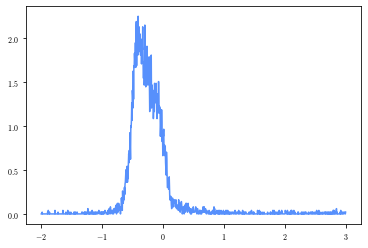

In [7]:
plt.plot(deltas, L[0])

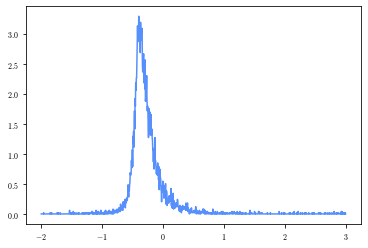

In [8]:
plt.plot(deltas, L[1])

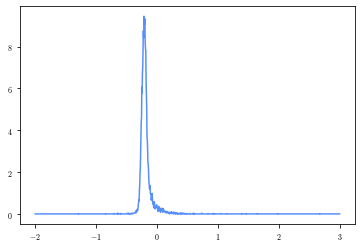

In [9]:
plt.plot(deltas, L[-1])

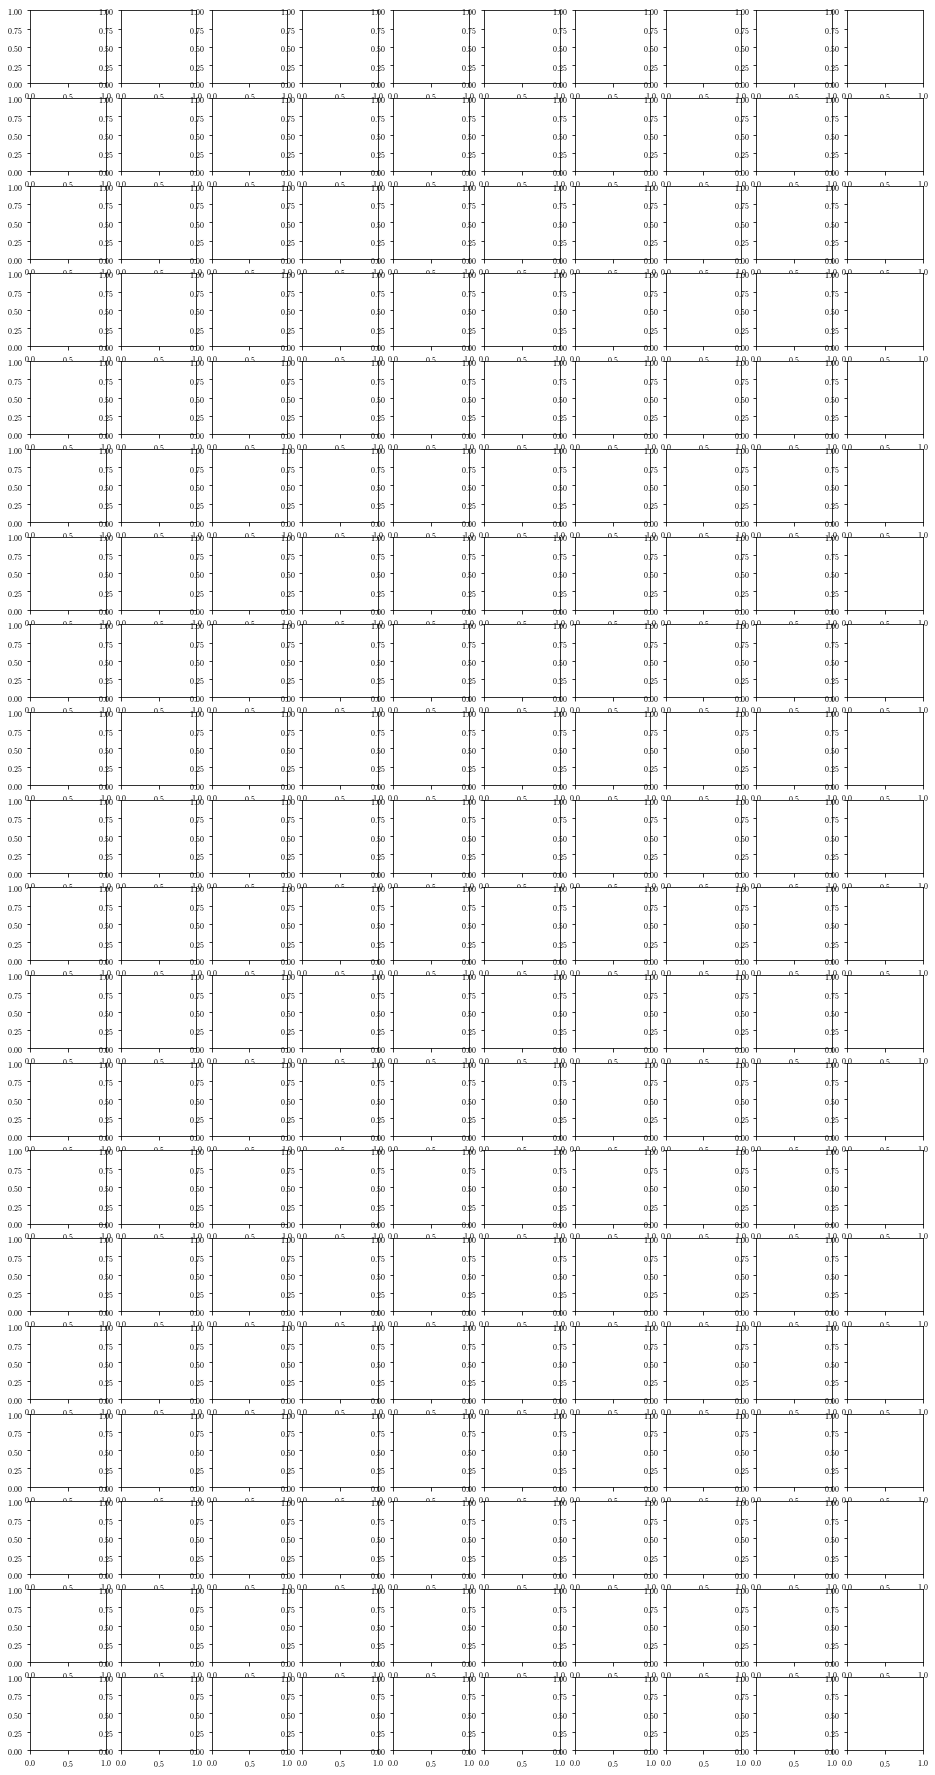

In [10]:
fig, axes = plt.subplots(20, 10, figsize=(16, 32))

IndexError: index 100 is out of bounds for axis 0 with size 100

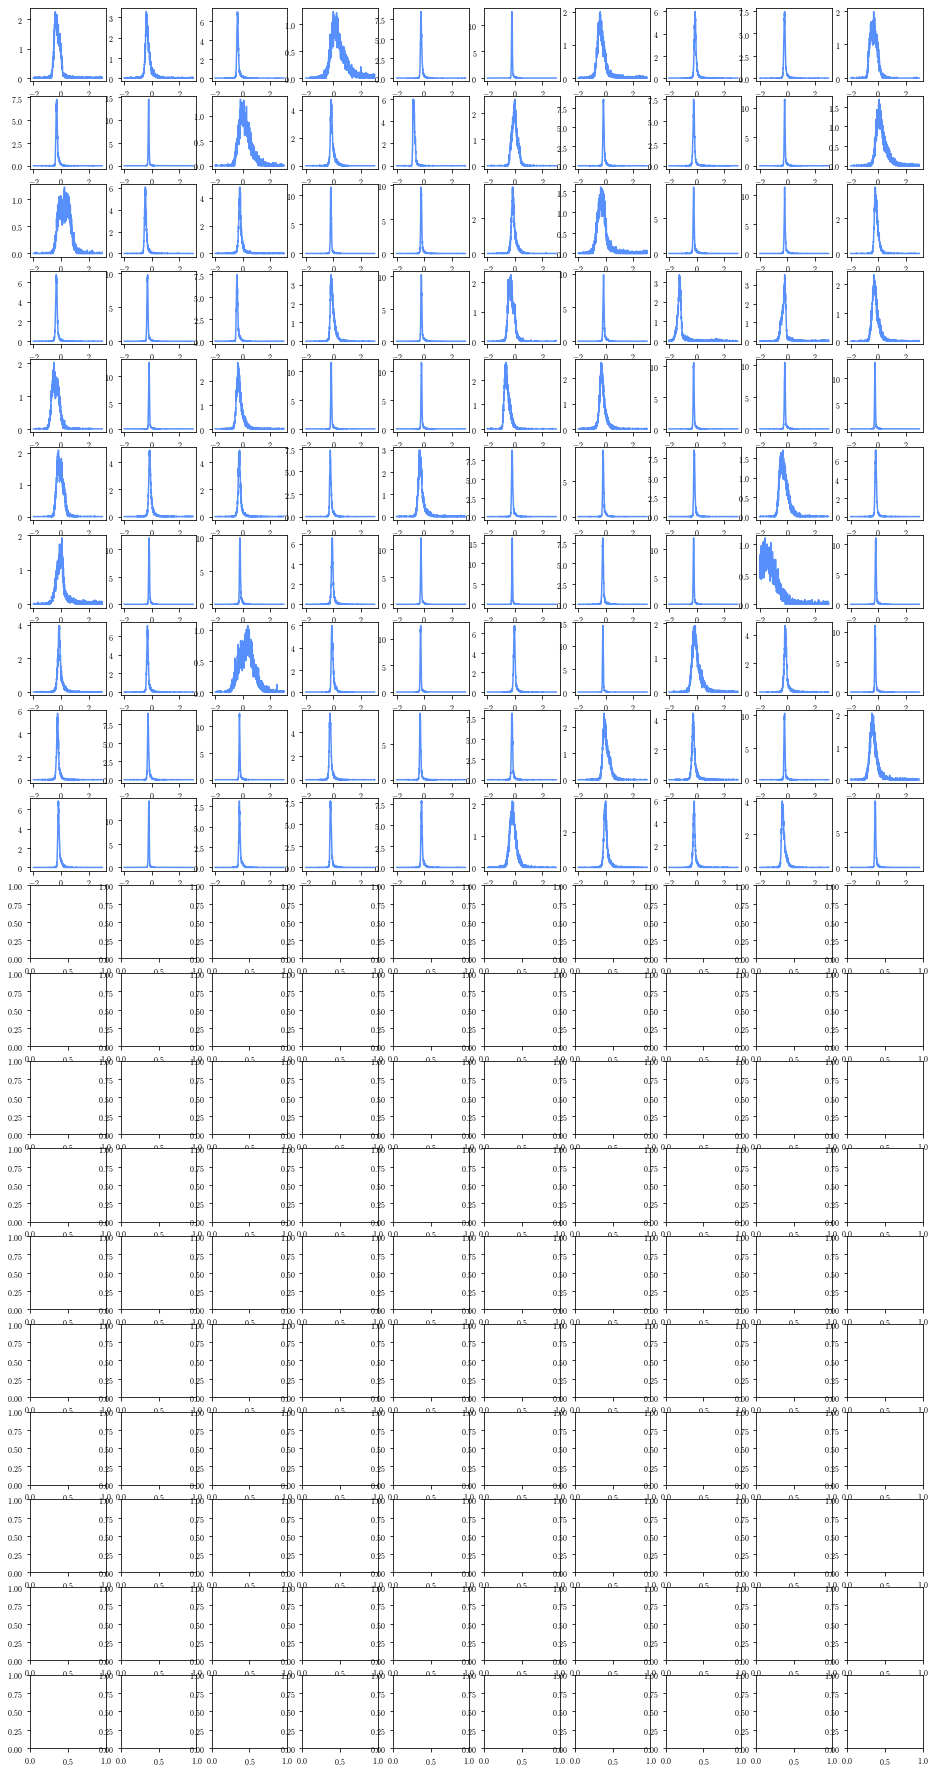

In [11]:
fig, axes = plt.subplots(20, 10, figsize=(16, 32))

for i, ax in enumerate(axes.flatten()):
    ax.plot(deltas, L[i])

In [12]:
# and a dictionary to store the likelihoods
likelihood_dict = {}

# loop over the background catalogs
for file in bg_dir.glob("*.pkl"):
    stem = str(file.stem).removesuffix("_bg")
    print("calculating likelihoods for", stem)

    # load the catalog
    catalog = pd.read_pickle(file)

    # select the correct flow ensemble
    if "euclid" in stem:
        name = "euclid"
        ensemble = flow_ensembles["lsst+euclid"]
    elif "roman" in stem:
        name = "roman"
        ensemble = flow_ensembles["lsst+roman"]
    elif "perfect" in stem:
        name = "perfect"
        ensemble = flow_ensembles["perfect"]
    else:
        name = int(stem[5:])  # type: ignore
        ensemble = flow_ensembles["lsst"]

    if name != "perfect":
        continue

    # loop over batches
    likelihoods = []
    batch_size = 100
    for idx in range(0, len(catalog), batch_size):
        # get the batch
        batch = catalog[idx : idx + batch_size]

        if name == "perfect":
            # for the perfect catalog, we will draw a ton more samples and
            # build a histogram
            z_samples, u_samples = sample_with_errors(batch, ensemble, 10_000, seed=idx)

            # flag the bad samples
            u_samples[z_samples < 2.36] = np.nan  # type: ignore

            # calculate Delta u from the samples of u and the true u
            delta_samples = u_samples - batch.u.to_numpy()[:, None]

            # create the histogram likelihoods
            bins = np.linspace(
                deltas.min(), deltas.max(), 100
            )
            Ldu = [
                np.histogram(samples, bins, density=True)[0]
                for samples in delta_samples
            ]
            Ldu = np.array(Ldu)

        else:
            # draw redshift samples
            z_samples, u_samples = sample_with_errors(batch, ensemble, seed=idx)  # type: ignore

            # flag the bad samples
            u_samples[z_samples < 2.36] = np.nan

            # add the grid of deltas
            u_alpha = u_samples[:, None, :] + deltas[None, :, None]

            # convert to flux
            u_alpha = 10 ** (u_alpha / -2.5)
            u_alpha_hat = 10 ** (batch.u.to_numpy() / -2.5)
            u_alpha_err = u_alpha_hat * (10 ** (batch.u_err.to_numpy() / -2.5) - 1)

            # calculate the likelihoods
            Ldu = np.exp(
                -((u_alpha - u_alpha_hat[:, None, None]) ** 2)
                / (2 * u_alpha_err[:, None, None] ** 2)
            ) / np.sqrt(2 * np.pi * u_alpha_err[:, None, None] ** 2)
            Ldu = np.nanmean(Ldu, axis=2)

            # normalize
            norms = np.trapz(Ldu, deltas)
            norms[norms > 0] = 1 / norms[norms > 0]
            norms[norms <= 0] = 0
            Ldu = norms[:, None] * Ldu

        # add to the list!
        likelihoods.append(Ldu)
        break

    likelihoods = np.vstack(likelihoods)  # type: ignore
    likelihood_dict[name] = likelihoods

calculating likelihoods for lsstY10
calculating likelihoods for lsstY10+euclid
calculating likelihoods for lsstY10+roman
calculating likelihoods for lsstY1
calculating likelihoods for lsstY5
calculating likelihoods for perfect


In [13]:
L = likelihood_dict["perfect"]

ValueError: x and y must have same first dimension, but have shapes (1000,) and (99,)

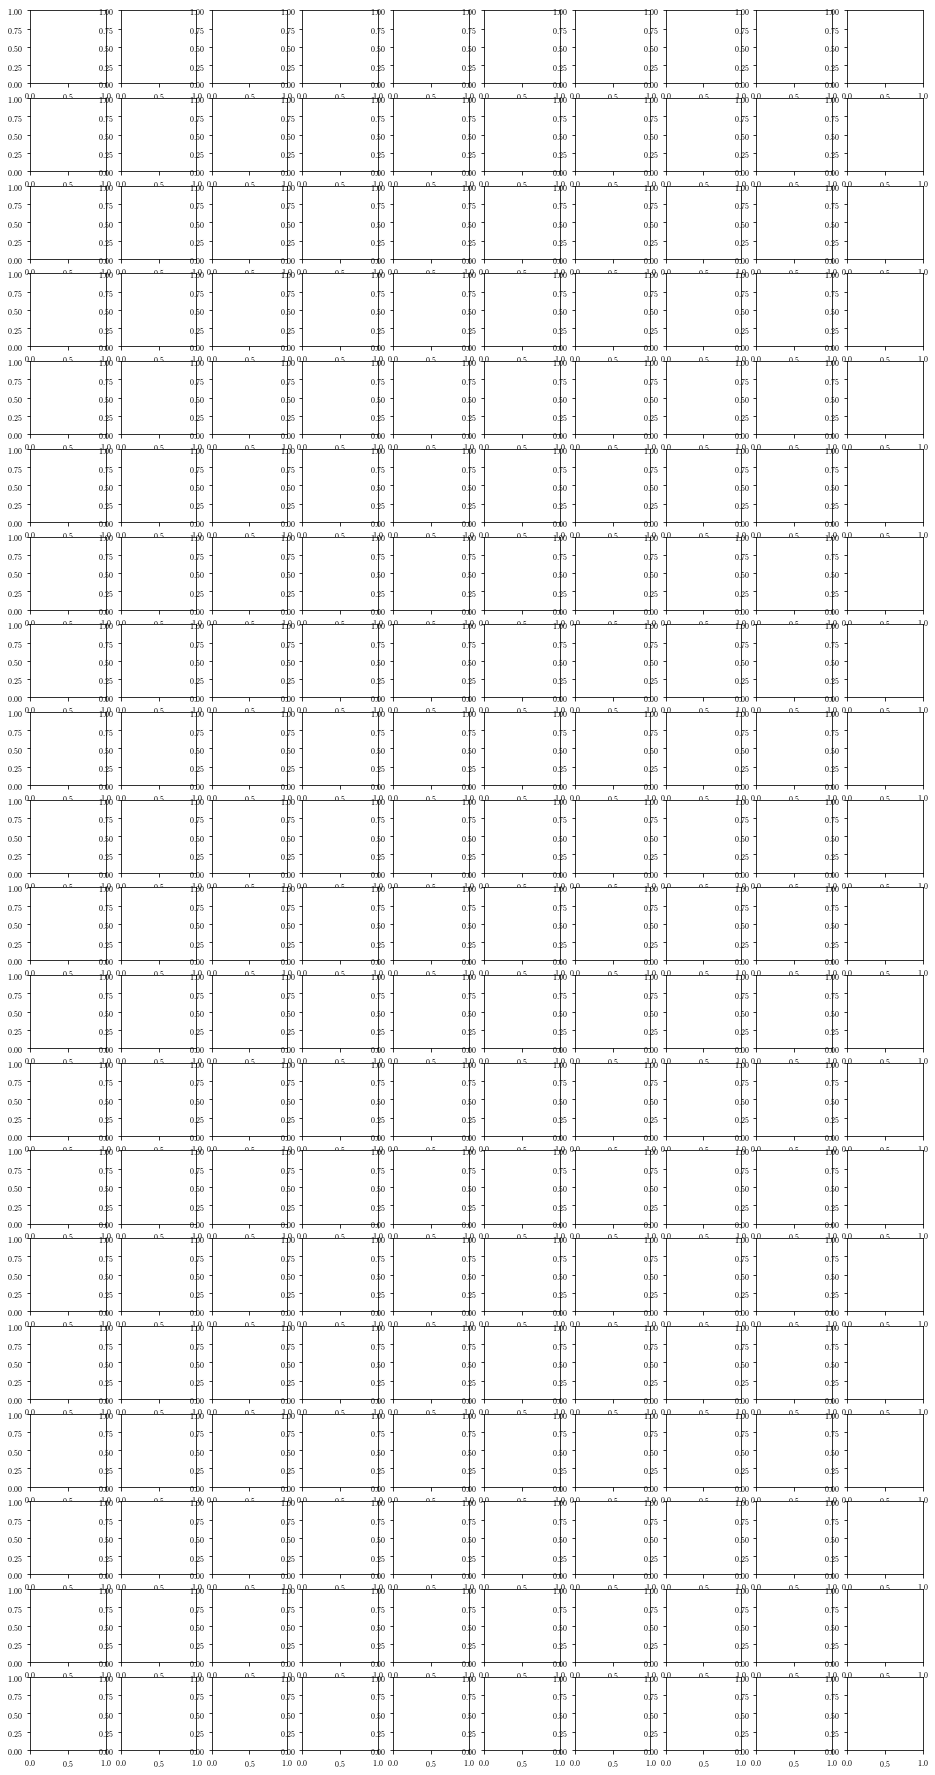

In [14]:
fig, axes = plt.subplots(20, 10, figsize=(16, 32))

for i, ax in enumerate(axes.flatten()):
    ax.plot(deltas, L[i])

IndexError: index 100 is out of bounds for axis 0 with size 100

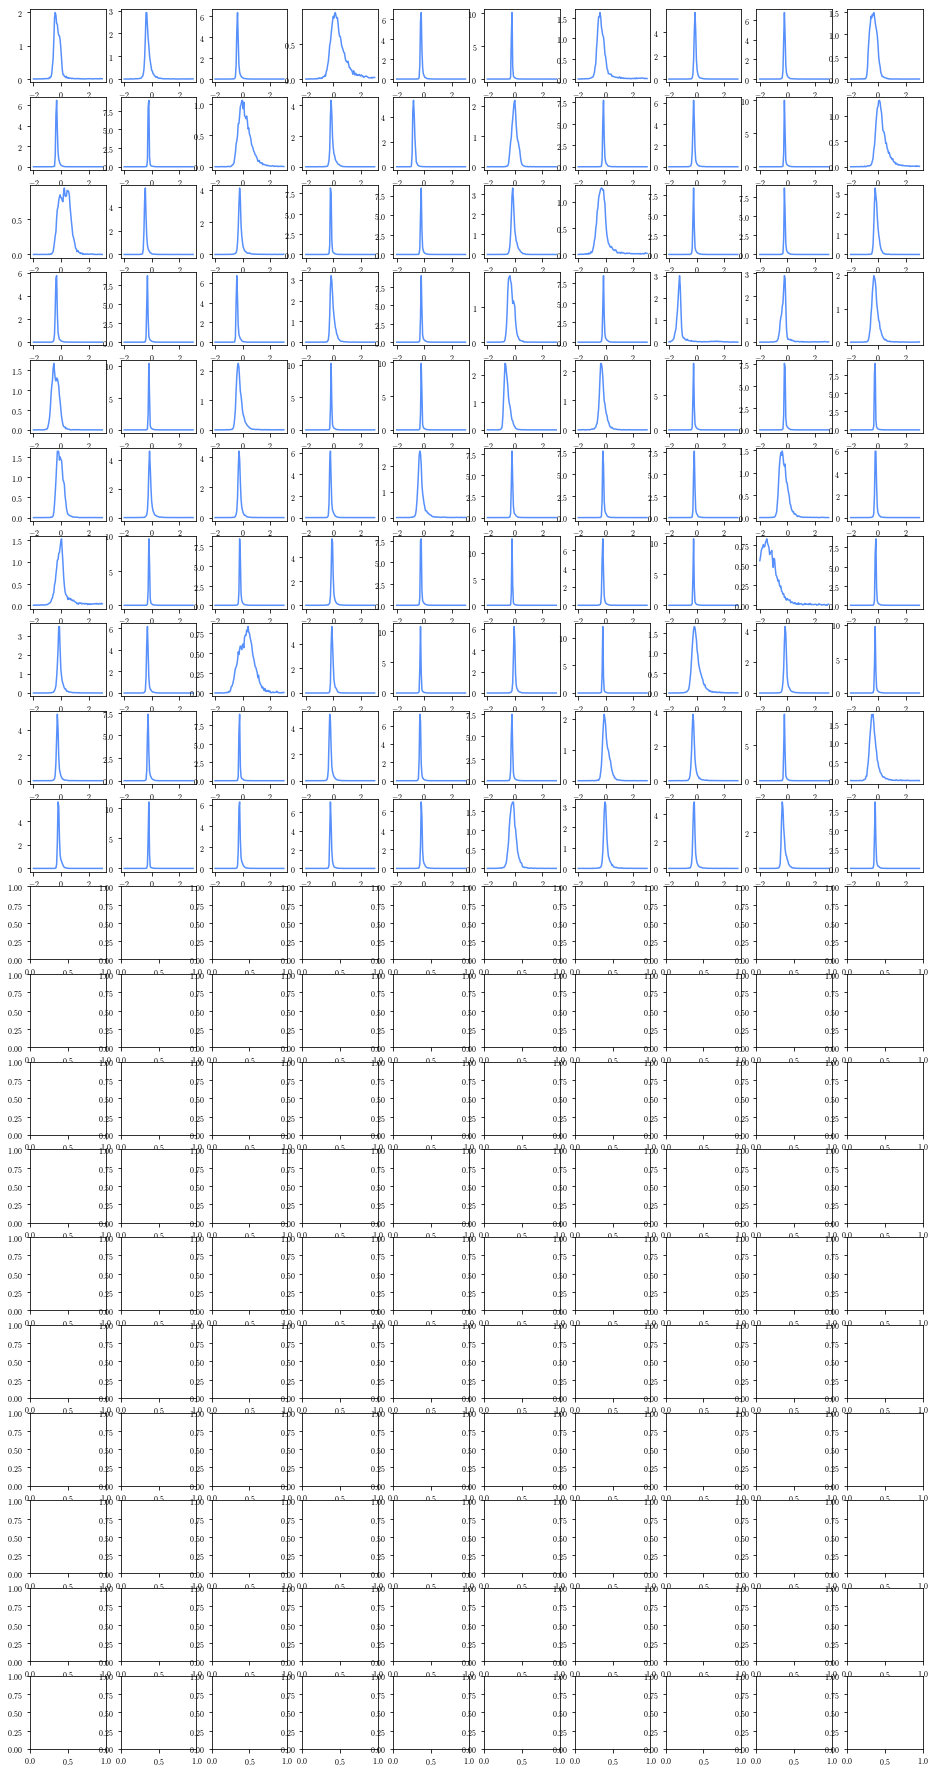

In [15]:
fig, axes = plt.subplots(20, 10, figsize=(16, 32))
x = np.linspace(deltas.min(), deltas.max(), len(L[0]))
for i, ax in enumerate(axes.flatten()):
    ax.plot(x, L[i])

In [16]:
LL = np.log(L).sum(axis=0)
LL = np.exp(LL - LL.max())
LL /= np.trapz(LL, deltas)

<ipython-input-16-292d560adc4b>:1: RuntimeWarning: divide by zero encountered in log
  LL = np.log(L).sum(axis=0)


ValueError: operands could not be broadcast together with shapes (999,) (98,) 

In [17]:
LL = np.log(L).sum(axis=0)
LL = np.exp(LL - LL.max())
LL /= np.trapz(LL, x)

<ipython-input-17-87b488bc8346>:1: RuntimeWarning: divide by zero encountered in log
  LL = np.log(L).sum(axis=0)


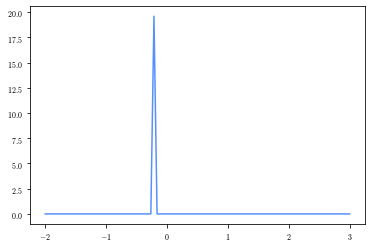

In [18]:
plt.plot(x, LL)

In [52]:
z_samples, u_samples = sample_with_errors(catalog, ensemble, seed=0)

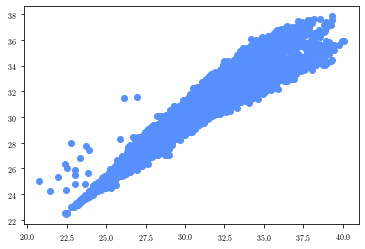

In [20]:
plt.scatter(catalog.u - 0.2, u_samples.mean(axis=1))

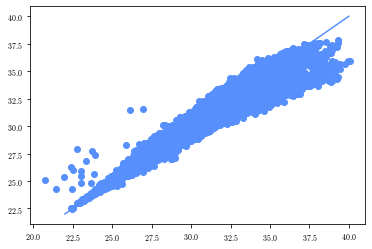

In [21]:
plt.scatter(catalog.u - 0.2, u_samples.mean(axis=1))
plt.plot([22, 40], [22, 40])

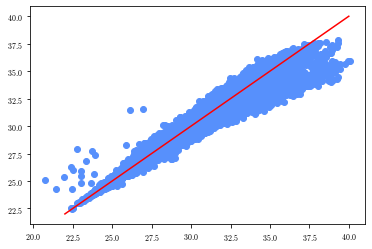

In [22]:
plt.scatter(catalog.u - 0.2, u_samples.mean(axis=1))
plt.plot([22, 40], [22, 40], c="r")

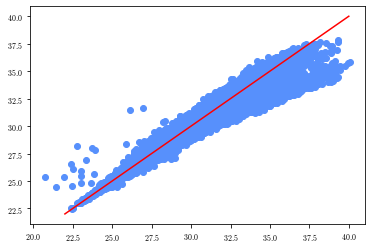

In [23]:
plt.scatter(catalog.u - 0.2, np.median(u_samples, axis=1))
plt.plot([22, 40], [22, 40], c="r")

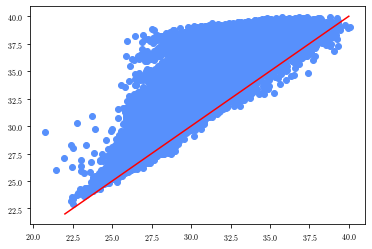

In [24]:
plt.scatter(catalog.u - 0.2, u_samples.max(axis=1))
plt.plot([22, 40], [22, 40], c="r")

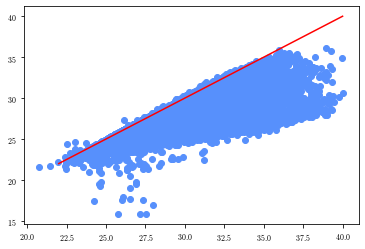

In [25]:
plt.scatter(catalog.u - 0.2, u_samples.min(axis=1))
plt.plot([22, 40], [22, 40], c="r")

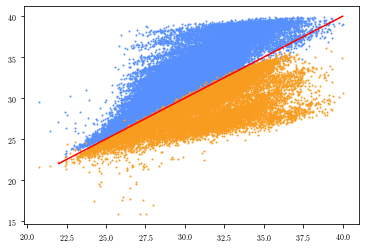

In [26]:
plt.scatter(catalog.u - 0.2, u_samples.max(axis=1), s=1)
plt.scatter(catalog.u - 0.2, u_samples.min(axis=1), s=1)
plt.plot([22, 40], [22, 40], c="r")

In [27]:
from utils import lya_decrement

In [29]:
lya_decrement(0, "u", 0)

array(-0.)

In [30]:
lya_decrement(4, "u", 0)

array(0.20548664)

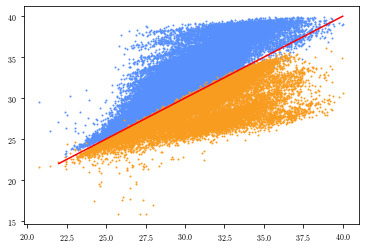

In [31]:
plt.scatter(catalog.u - 0.20548664, u_samples.max(axis=1), s=1)
plt.scatter(catalog.u - 0.20548664, u_samples.min(axis=1), s=1)
plt.plot([22, 40], [22, 40], c="r")

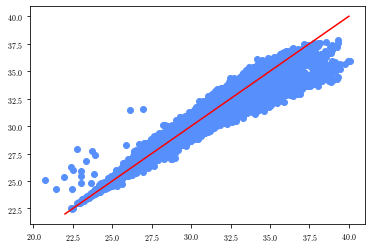

In [32]:
plt.scatter(catalog.u - 0.20548664, u_samples.mean(axis=1))
plt.plot([22, 40], [22, 40], c="r")

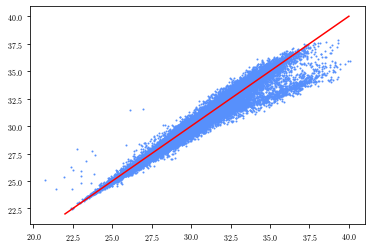

In [33]:
plt.scatter(catalog.u - 0.20548664, u_samples.mean(axis=1), s=1)
plt.plot([22, 40], [22, 40], c="r")

(array([1.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00,
        2.000e+00, 0.000e+00, 2.000e+00, 3.000e+00, 1.000e+00, 2.000e+00,
        6.000e+00, 9.000e+00, 1.100e+01, 6.000e+00, 1.000e+01, 1.700e+01,
        1.200e+01, 1.900e+01, 2.300e+01, 1.700e+01, 2.400e+01, 2.100e+01,
        3.000e+01, 2.800e+01, 4.300e+01, 5.100e+01, 4.400e+01, 4.500e+01,
        4.200e+01, 7.900e+01, 7.300e+01, 6.300e+01, 8.900e+01, 1.070e+02,
        1.050e+02, 1.300e+02, 1.300e+02, 1.460e+02, 1.510e+02, 1.910e+02,
        1.950e+02, 1.900e+02, 2.400e+02, 2.320e+02, 2.750e+02, 3.020e+02,
        3.290e+02, 3.600e+02, 4.210e+02, 4.490e+02, 5.100e+02, 5.350e+02,
        5.740e+02, 6.490e+02, 7.760e+02, 8.880e+02, 1.052e+03, 1.193e+03,
        1.376e+03, 1.518e+03, 1.780e+03, 1.997e+03, 2.188e+03, 2.403e+03,
        2.563e+03, 2.866e+03, 3.076e+0

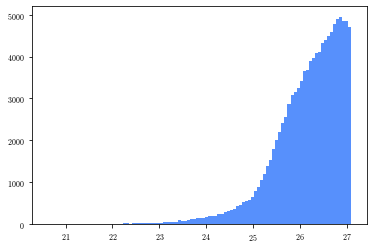

In [34]:
plt.hist(catalog.i, bins=100)

(array([1.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00,
        1.000e+00, 0.000e+00, 5.000e+00, 2.000e+00, 3.000e+00, 6.000e+00,
        1.000e+01, 1.400e+01, 1.500e+01, 2.900e+01, 5.700e+01, 5.900e+01,
        9.500e+01, 1.100e+02, 1.270e+02, 2.070e+02, 2.800e+02, 3.950e+02,
        5.920e+02, 8.990e+02, 1.352e+03, 1.830e+03, 2.600e+03, 3.181e+03,
        3.837e+03, 4.561e+03, 5.022e+03, 5.796e+03, 5.832e+03, 5.172e+03,
        4.724e+03, 4.285e+03, 3.982e+03, 3.598e+03, 3.160e+03, 3.032e+03,
        2.978e+03, 2.679e+03, 2.538e+03, 2.317e+03, 2.074e+03, 2.038e+03,
        1.794e+03, 1.839e+03, 1.752e+03, 1.652e+03, 1.611e+03, 1.575e+03,
        1.608e+03, 1.545e+03, 1.554e+03, 1.505e+03, 1.473e+03, 1.563e+03,
        1.461e+03, 1.397e+03, 1.314e+03, 1.119e+03, 1.002e+03, 7.830e+02,
        7.120e+02, 5.680e+02, 4.970e+02, 3.810e+02, 3.450e+02, 2.890e+02,
        2.750e+02, 2.030e+02, 1.690e+02, 1.680e+02, 1.540e+02, 1.320e+02,
        1.140e+02, 9.500e+01, 8.300e+0

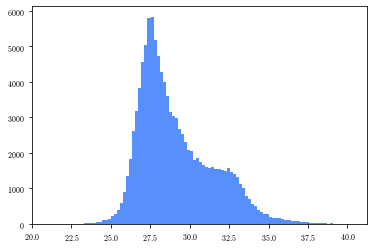

In [35]:
plt.hist(catalog.u, bins=100)

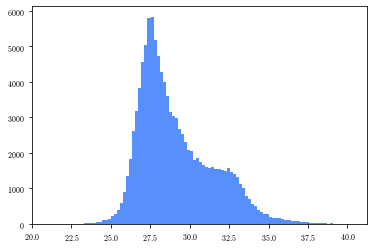

In [36]:
plt.hist(catalog.u, bins=100);

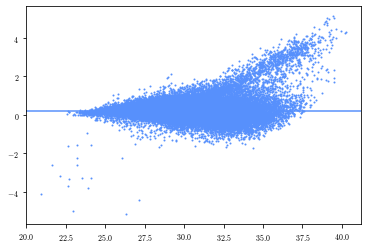

In [37]:
plt.scatter(catalog.u, catalog.u - u_samples.mean(axis=1), s=1)
plt.axhline(0.20548664)
#plt.plot([22, 40], [22, 40], c="r")

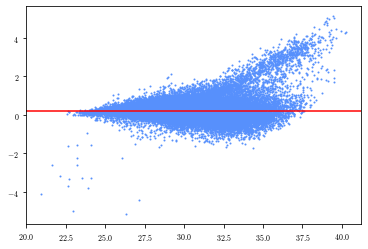

In [38]:
plt.scatter(catalog.u, catalog.u - u_samples.mean(axis=1), s=1)
plt.axhline(0.20548664, c="r")
#plt.plot([22, 40], [22, 40], c="r")

In [42]:
flag = u_samples.mean(axis=1) < 30

In [43]:
LL = np.log(L[flag]).sum(axis=0)
LL = np.exp(LL - LL.max())
LL /= np.trapz(LL, deltas)

<ipython-input-43-ffa64f988834>:1: RuntimeWarning: divide by zero encountered in log
  LL = np.log(L[flag]).sum(axis=0)


ValueError: operands could not be broadcast together with shapes (999,) (98,) 

In [41]:
# and a dictionary to store the likelihoods
likelihood_dict = {}

# loop over the background catalogs
for file in bg_dir.glob("*.pkl"):
    stem = str(file.stem).removesuffix("_bg")
    print("calculating likelihoods for", stem)

    # load the catalog
    catalog = pd.read_pickle(file)

    # select the correct flow ensemble
    if "euclid" in stem:
        name = "euclid"
        ensemble = flow_ensembles["lsst+euclid"]
    elif "roman" in stem:
        name = "roman"
        ensemble = flow_ensembles["lsst+roman"]
    elif "perfect" in stem:
        name = "perfect"
        ensemble = flow_ensembles["perfect"]
    else:
        name = int(stem[5:])  # type: ignore
        ensemble = flow_ensembles["lsst"]

    if name != "perfect":
        continue

    # loop over batches
    likelihoods = []
    batch_size = 100
    for idx in range(0, len(catalog), batch_size):
        # get the batch
        batch = catalog[idx : idx + batch_size]

        if name == "perfect":
            # for the perfect catalog, we will draw a ton more samples and
            # build a histogram
            z_samples, u_samples = sample_with_errors(batch, ensemble, 10_000, seed=idx)

            # flag the bad samples
            u_samples[z_samples < 2.36] = np.nan  # type: ignore

            # calculate Delta u from the samples of u and the true u
            delta_samples = u_samples - batch.u.to_numpy()[:, None]

            # create the histogram likelihoods
            bins = np.linspace(
                deltas.min(), deltas.max(), 100
            )
            Ldu = [
                np.histogram(samples, bins, density=True)[0]
                for samples in delta_samples
            ]
            Ldu = np.array(Ldu)

        else:
            # draw redshift samples
            z_samples, u_samples = sample_with_errors(batch, ensemble, seed=idx)  # type: ignore

            # flag the bad samples
            u_samples[z_samples < 2.36] = np.nan

            # add the grid of deltas
            u_alpha = u_samples[:, None, :] + deltas[None, :, None]

            # convert to flux
            u_alpha = 10 ** (u_alpha / -2.5)
            u_alpha_hat = 10 ** (batch.u.to_numpy() / -2.5)
            u_alpha_err = u_alpha_hat * (10 ** (batch.u_err.to_numpy() / -2.5) - 1)

            # calculate the likelihoods
            Ldu = np.exp(
                -((u_alpha - u_alpha_hat[:, None, None]) ** 2)
                / (2 * u_alpha_err[:, None, None] ** 2)
            ) / np.sqrt(2 * np.pi * u_alpha_err[:, None, None] ** 2)
            Ldu = np.nanmean(Ldu, axis=2)

            # normalize
            norms = np.trapz(Ldu, deltas)
            norms[norms > 0] = 1 / norms[norms > 0]
            norms[norms <= 0] = 0
            Ldu = norms[:, None] * Ldu

        # add to the list!
        likelihoods.append(Ldu)
        break

    likelihoods = np.vstack(likelihoods)  # type: ignore
    likelihood_dict[name] = likelihoods

calculating likelihoods for lsstY10
calculating likelihoods for lsstY10+euclid
calculating likelihoods for lsstY10+roman
calculating likelihoods for lsstY1
calculating likelihoods for lsstY5
calculating likelihoods for perfect


In [44]:
batch

,redshift,u,g,r,i,z,y,Y,J,H,...,u_err,g_err,r_err,i_err,z_err,y_err,Y_err,J_err,H_err,F_err
7,3.429946,33.079677,27.521906,26.608847,26.586004,26.781363,26.874483,26.858116,26.686022,26.487396,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
16,3.258337,31.745455,26.851946,26.128769,26.198679,26.484606,26.534178,26.468658,26.393900,26.236490,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
20,2.754195,27.684918,26.110250,25.969150,26.174213,26.261133,26.234276,26.234867,26.241310,25.875393,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
24,3.297755,32.077649,26.709707,25.375500,25.307333,25.483479,25.546642,25.453540,25.167492,24.757399,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
31,2.760499,27.063458,25.688880,25.470388,25.527096,25.570541,25.536112,25.488290,25.306063,24.579845,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
618,3.090418,27.209002,24.245255,23.755468,23.927880,24.389647,24.282118,24.193588,24.137940,23.949875,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
619,3.165696,31.219952,27.297260,26.511663,26.533937,26.715990,26.702776,26.631120,26.451202,26.012411,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
639,3.094963,29.253606,26.206194,25.758550,25.815117,25.951332,25.949368,25.924036,25.860674,25.469162,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
646,2.488271,28.025731,26.565546,26.306768,26.527220,26.334839,26.215815,26.119144,25.685158,24.988533,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [45]:
flag = batch.u.mean(axis=1) < 30

ValueError: No axis named 1 for object type Series

In [46]:
flag = batch.u < 30

In [47]:
LL = np.log(L[flag]).sum(axis=0)
LL = np.exp(LL - LL.max())
LL /= np.trapz(LL, deltas)

<ipython-input-47-ffa64f988834>:1: RuntimeWarning: divide by zero encountered in log
  LL = np.log(L[flag]).sum(axis=0)


ValueError: operands could not be broadcast together with shapes (999,) (98,) 

In [48]:
LL = np.log(L[flag]).sum(axis=0)
#LL = np.exp(LL - LL.max())
#LL /= np.trapz(LL, deltas)

<ipython-input-48-65ff496d919f>:1: RuntimeWarning: divide by zero encountered in log
  LL = np.log(L[flag]).sum(axis=0)


In [49]:
LL.shape

(99,)

In [50]:
LL = np.log(L[flag]).sum(axis=0)
LL = np.exp(LL - LL.max())
LL /= np.trapz(LL, x)

<ipython-input-50-1211986286bd>:1: RuntimeWarning: divide by zero encountered in log
  LL = np.log(L[flag]).sum(axis=0)


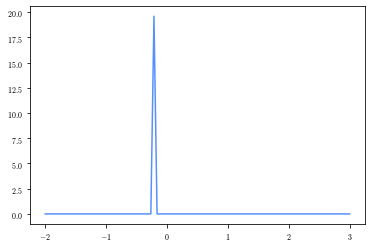

In [51]:
plt.plot(x, LL)

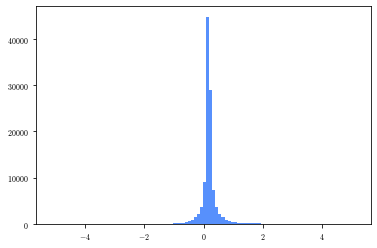

In [53]:
plt.hist(catalog.u - u_samples.mean(axis=1), bins=100);

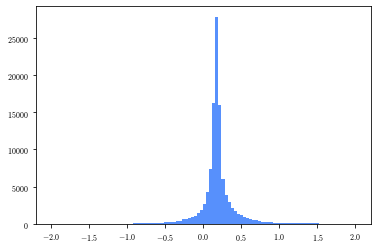

In [54]:
plt.hist(catalog.u - u_samples.mean(axis=1), range=(-2, 2), bins=100);

In [55]:
np.mean(catalog.u - u_samples.mean(axis=1))

0.21188131780581154

In [56]:
np.std(catalog.u - u_samples.mean(axis=1))

0.34029515885587097

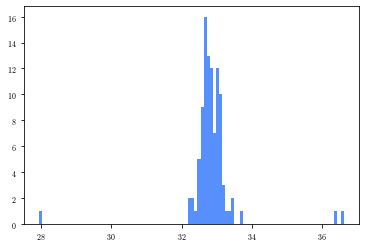

In [57]:
plt.hist(u_samples[0], bins=100);

In [58]:
plt.hist(catalog.u - u_samples[0], bins=100);

ValueError: operands could not be broadcast together with shapes (110723,) (100,) 

In [59]:
idx = 0
plt.hist(catalog.u[idx] - u_samples[idx], bins=100);

KeyError: 0

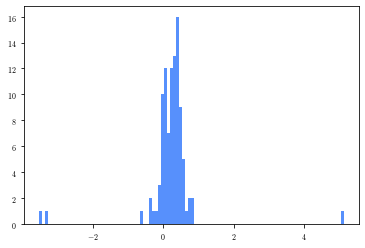

In [60]:
idx = 0
plt.hist(catalog.u.iloc[idx] - u_samples[idx], bins=100);

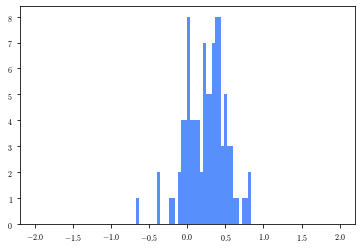

In [61]:
idx = 0
plt.hist(catalog.u.iloc[idx] - u_samples[idx], bins=100, range=(-2, 2));

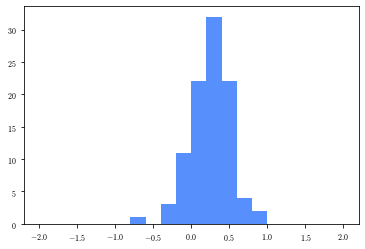

In [62]:
idx = 0
plt.hist(catalog.u.iloc[idx] - u_samples[idx], bins=20, range=(-2, 2));

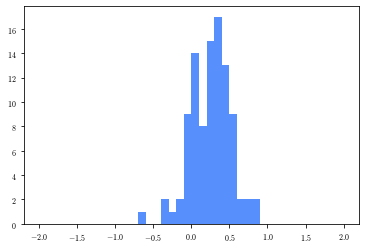

In [63]:
idx = 0
plt.hist(catalog.u.iloc[idx] - u_samples[idx], bins=40, range=(-2, 2));

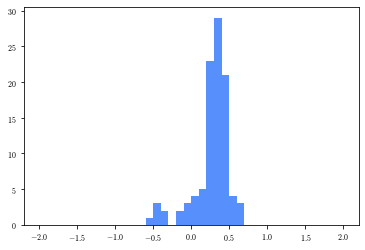

In [64]:
idx = 1
plt.hist(catalog.u.iloc[idx] - u_samples[idx], bins=40, range=(-2, 2));

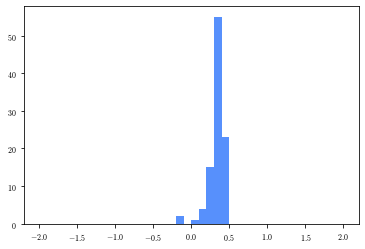

In [65]:
idx = 2
plt.hist(catalog.u.iloc[idx] - u_samples[idx], bins=40, range=(-2, 2));

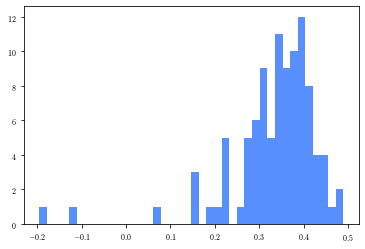

In [66]:
idx = 2
plt.hist(catalog.u.iloc[idx] - u_samples[idx], bins=40);

KeyError: 0

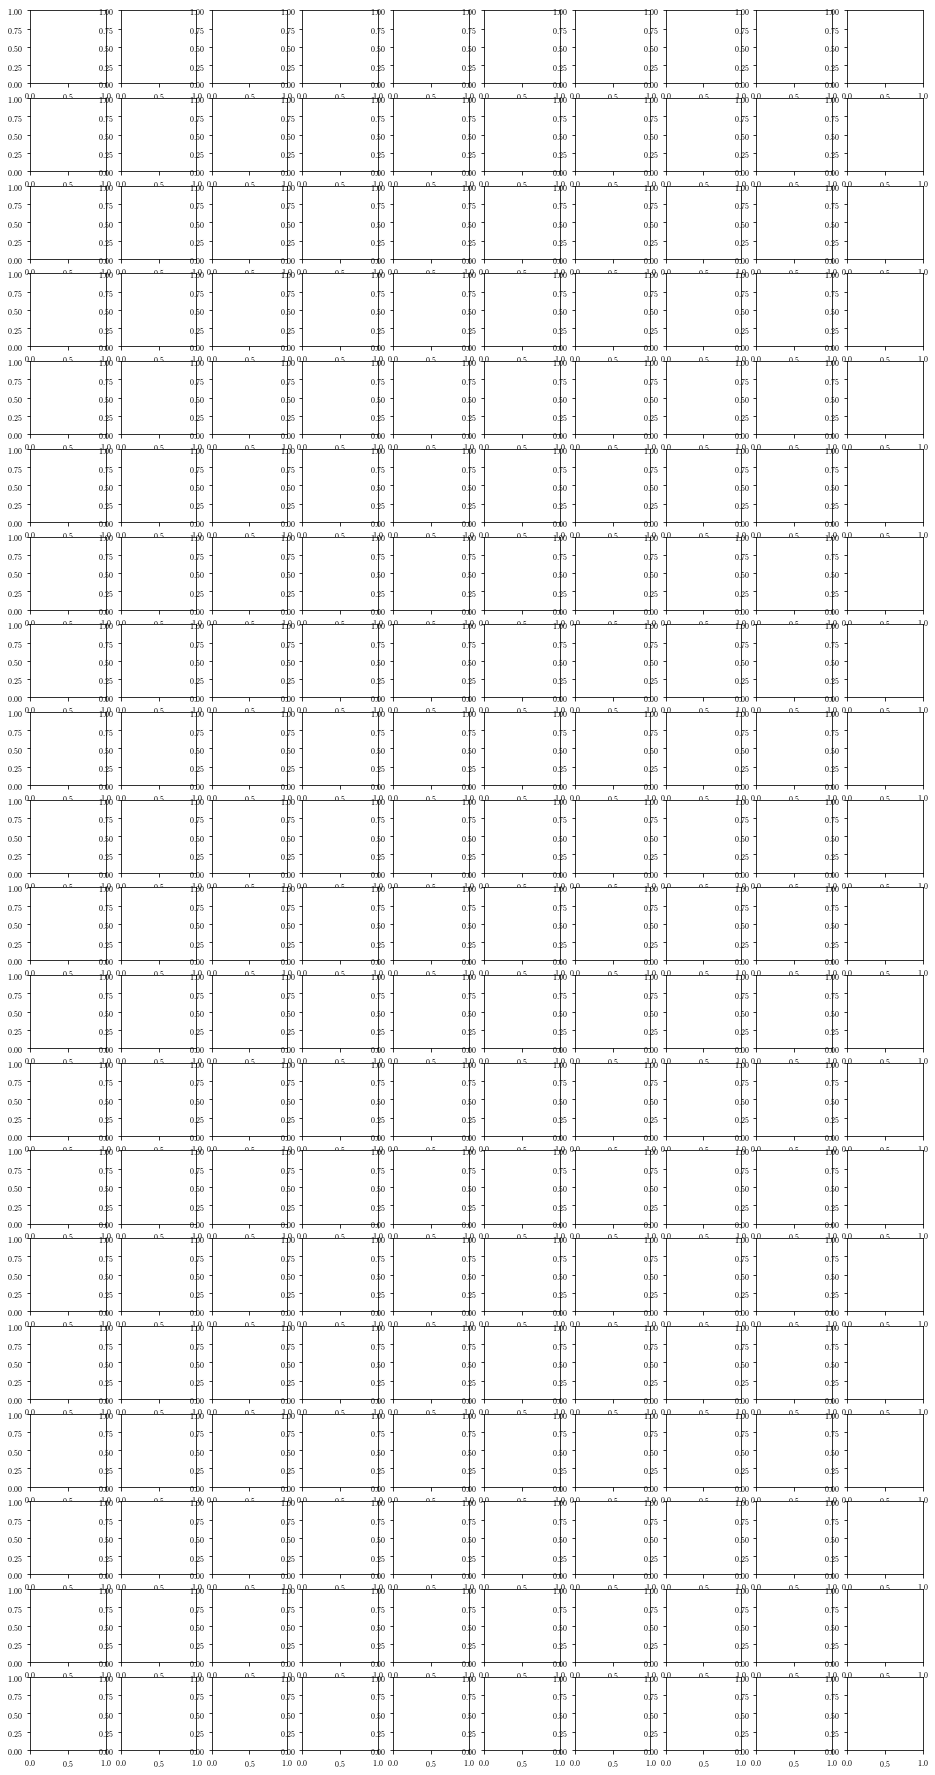

In [67]:
fig, axes = plt.subplots(20, 10, figsize=(16, 32))
for i, ax in enumerate(axes.flatten()):
    ax.hist(catalog.u.loc[i] - u_samples[i], bins=40)

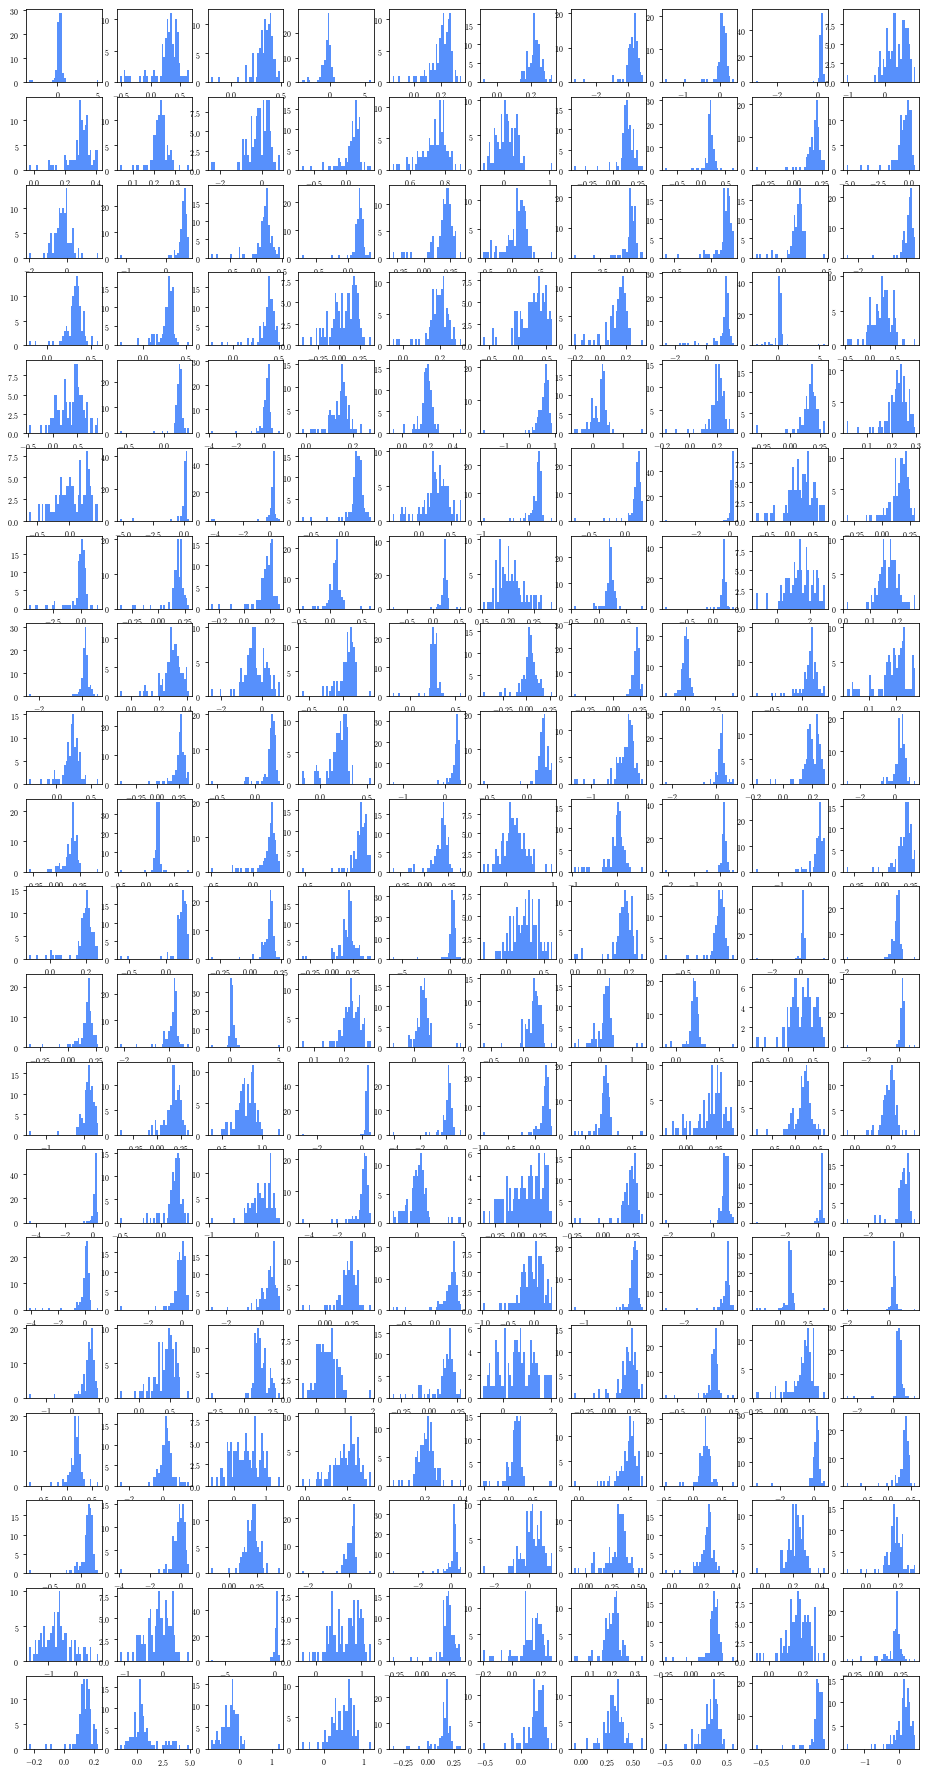

In [68]:
fig, axes = plt.subplots(20, 10, figsize=(16, 32))
for i, ax in enumerate(axes.flatten()):
    ax.hist(catalog.u.iloc[i] - u_samples[i], bins=40)

In [70]:
z_samples, u_samples = sample_with_errors(catalog, ensemble, m_samples=10_000, seed=0)

In [1]:
import pickle
from random import sample

import numpy as np
import pandas as pd
from pzflow import FlowEnsemble
from showyourwork.paths import user as Paths
from utils import sample_with_errors

# instantiate the paths
paths = Paths()

# load the flow ensembles
model_dir = paths.data / "models"
flow_ensembles = {
    "lsst": FlowEnsemble(file=model_dir / "lsst_ensemble.pzflow.pkl"),
    "lsst+euclid": FlowEnsemble(file=model_dir / "lsst+euclid_ensemble.pzflow.pkl"),
    "lsst+roman": FlowEnsemble(file=model_dir / "lsst+roman_ensemble.pzflow.pkl"),
    "perfect": FlowEnsemble(file=model_dir / "lsst+roman_ensemble.pzflow.pkl"),
}

# directory where the background catalogs are saved
bg_dir = paths.data / "background_catalogs"

# setup the grid of Delta u's on which to plot the likelihoods
deltas = np.linspace(-2, 3, 1000)

In [2]:
z_samples, u_samples = sample_with_errors(catalog, ensemble, m_samples=1_000, seed=0)

NameError: name 'catalog' is not defined

In [3]:
# and a dictionary to store the likelihoods
likelihood_dict = {}

# loop over the background catalogs
for file in bg_dir.glob("*.pkl"):
    stem = str(file.stem).removesuffix("_bg")
    print("calculating likelihoods for", stem)

    # load the catalog
    catalog = pd.read_pickle(file)

    # select the correct flow ensemble
    if "euclid" in stem:
        name = "euclid"
        ensemble = flow_ensembles["lsst+euclid"]
    elif "roman" in stem:
        name = "roman"
        ensemble = flow_ensembles["lsst+roman"]
    elif "perfect" in stem:
        name = "perfect"
        ensemble = flow_ensembles["perfect"]
    else:
        name = int(stem[5:])  # type: ignore
        ensemble = flow_ensembles["lsst"]

    if name != "perfect":
        continue

    # loop over batches
    likelihoods = []
    batch_size = 100
    for idx in range(0, len(catalog), batch_size):
        # get the batch
        batch = catalog[idx : idx + batch_size]

        if name == "perfect":
            # for the perfect catalog, we will draw a ton more samples and
            # build a histogram
            z_samples, u_samples = sample_with_errors(batch, ensemble, 10_000, seed=idx)

            # flag the bad samples
            u_samples[z_samples < 2.36] = np.nan  # type: ignore

            # calculate Delta u from the samples of u and the true u
            delta_samples = u_samples - batch.u.to_numpy()[:, None]

            # create the histogram likelihoods
            bins = np.linspace(
                deltas.min(), deltas.max(), 100
            )
            Ldu = [
                np.histogram(samples, bins, density=True)[0]
                for samples in delta_samples
            ]
            Ldu = np.array(Ldu)

        else:
            # draw redshift samples
            z_samples, u_samples = sample_with_errors(batch, ensemble, seed=idx)  # type: ignore

            # flag the bad samples
            u_samples[z_samples < 2.36] = np.nan

            # add the grid of deltas
            u_alpha = u_samples[:, None, :] + deltas[None, :, None]

            # convert to flux
            u_alpha = 10 ** (u_alpha / -2.5)
            u_alpha_hat = 10 ** (batch.u.to_numpy() / -2.5)
            u_alpha_err = u_alpha_hat * (10 ** (batch.u_err.to_numpy() / -2.5) - 1)

            # calculate the likelihoods
            Ldu = np.exp(
                -((u_alpha - u_alpha_hat[:, None, None]) ** 2)
                / (2 * u_alpha_err[:, None, None] ** 2)
            ) / np.sqrt(2 * np.pi * u_alpha_err[:, None, None] ** 2)
            Ldu = np.nanmean(Ldu, axis=2)

            # normalize
            norms = np.trapz(Ldu, deltas)
            norms[norms > 0] = 1 / norms[norms > 0]
            norms[norms <= 0] = 0
            Ldu = norms[:, None] * Ldu

        # add to the list!
        likelihoods.append(Ldu)
        break

    likelihoods = np.vstack(likelihoods)  # type: ignore
    likelihood_dict[name] = likelihoods

calculating likelihoods for lsstY10
calculating likelihoods for lsstY10+euclid
calculating likelihoods for lsstY10+roman
calculating likelihoods for lsstY1
calculating likelihoods for lsstY5
calculating likelihoods for perfect


In [4]:
z_samples, u_samples = sample_with_errors(catalog, ensemble, m_samples=1_000, seed=0)

2022-07-28 12:25:18.648609: W external/org_tensorflow/tensorflow/core/common_runtime/bfc_allocator.cc:290] Allocator (GPU_0_bfc) ran out of memory trying to allocate 5.29GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


XlaRuntimeError: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 5685794816 bytes.

In [5]:
z_samples, u_samples = sample_with_errors(catalog[:200], ensemble, m_samples=1_000, seed=0)

In [6]:
fig, axes = plt.subplots(20, 10, figsize=(16, 32))
for i, ax in enumerate(axes.flatten()):
    ax.hist(catalog.u.iloc[i] - u_samples[i], bins=40)

NameError: name 'plt' is not defined

In [7]:
import matplotlib.pyplot as plt

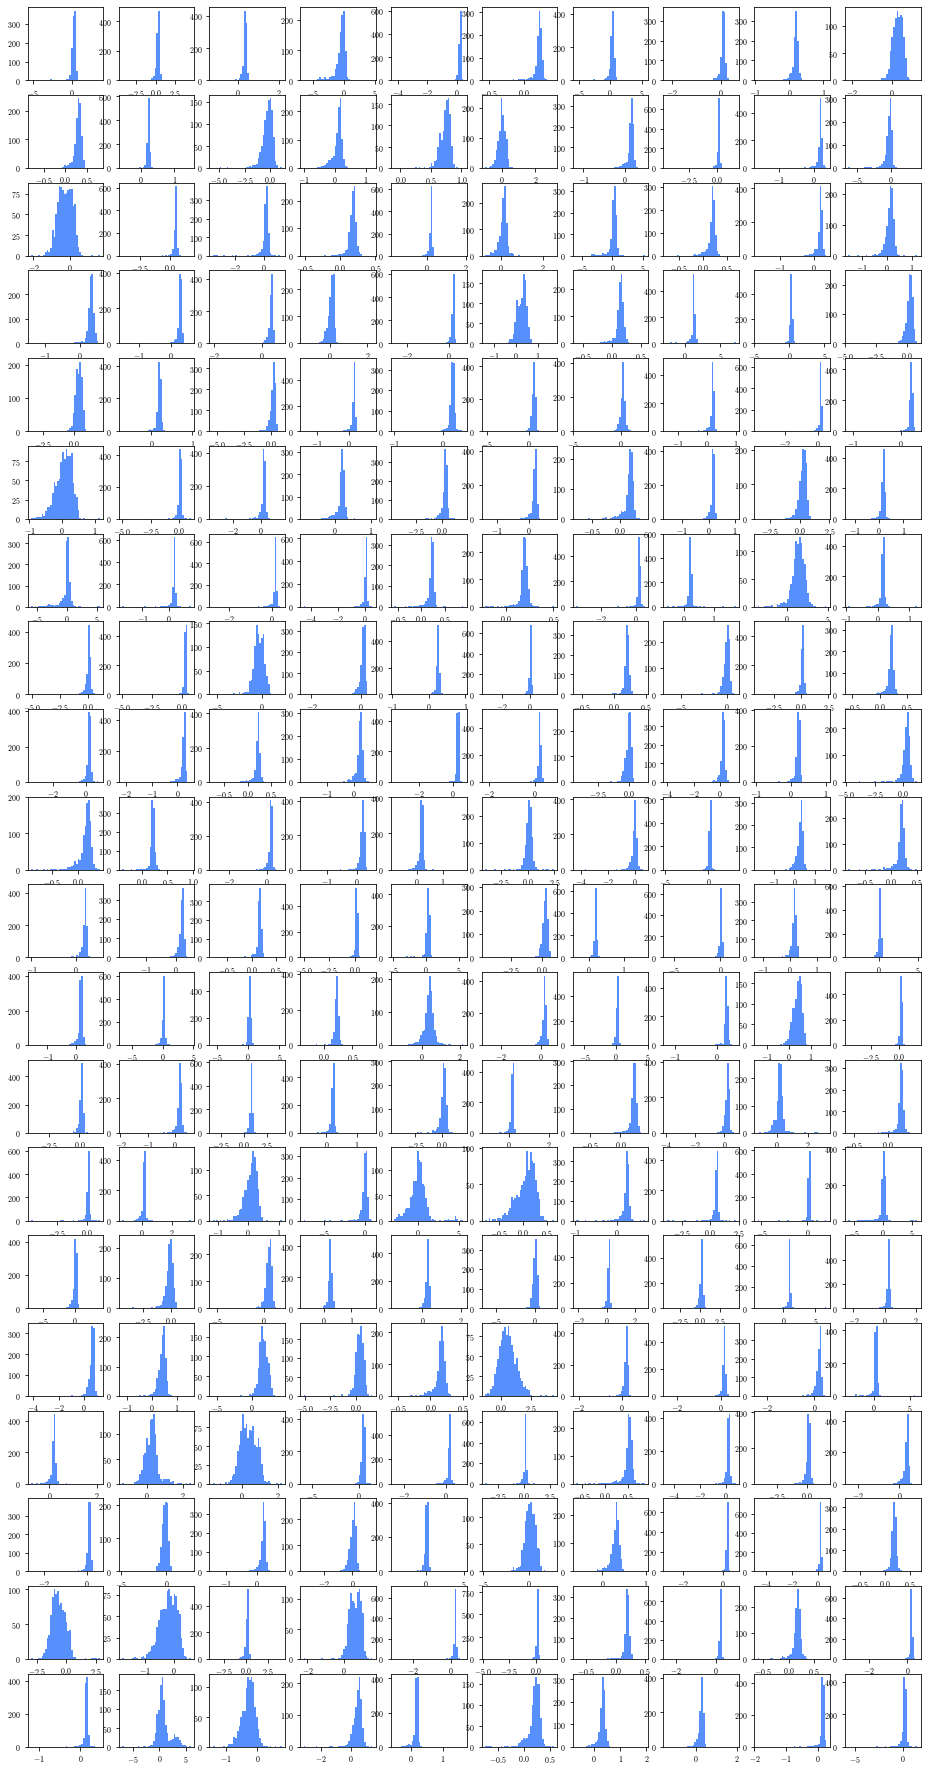

In [8]:
fig, axes = plt.subplots(20, 10, figsize=(16, 32))
for i, ax in enumerate(axes.flatten()):
    ax.hist(catalog.u.iloc[i] - u_samples[i], bins=40)

In [9]:
plt.scatter(catalog[:200].u - u_samples.mean(axis=1), s=1)

TypeError: scatter() missing 1 required positional argument: 'y'

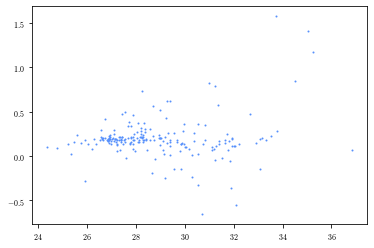

In [10]:
plt.scatter(catalog[:200].u, catalog[:200].u - u_samples.mean(axis=1), s=1)

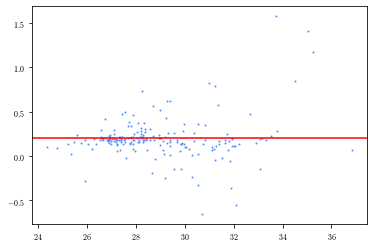

In [11]:
plt.scatter(catalog[:200].u, catalog[:200].u - u_samples.mean(axis=1), s=1)
plt.axhline(0.20548664, c="r")

In [12]:
z_samples, u_samples = sample_with_errors(catalog[:200], ensemble, seed=0)

In [13]:
plt.scatter(catalog.u, catalog.u - u_samples.mean(axis=1), s=1)
plt.axhline(0.20548664, c="r")

ValueError: operands could not be broadcast together with shapes (110723,) (200,) 

In [14]:
u_samples

array([[32.661774, 33.83613 , 32.802086, ..., 32.64271 , 33.030945,
        32.661404],
       [31.116747, 31.314474, 31.200397, ..., 31.331923, 31.43842 ,
        31.637163],
       [27.289679, 27.278088, 27.408907, ..., 27.262842, 27.288485,
        27.239208],
       ...,
       [26.836067, 26.79786 , 26.733318, ..., 26.876387, 26.889084,
        26.865345],
       [27.575405, 27.606539, 27.629726, ..., 27.624893, 27.544107,
        27.603285],
       [31.014095, 30.991463, 30.892208, ..., 30.879017, 30.887346,
        31.068264]], dtype=float32)

In [15]:
u_samples.shape

(200, 100)

In [16]:
z_samples, u_samples = sample_with_errors(catalog, ensemble, seed=0)

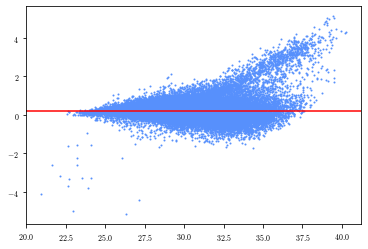

In [17]:
plt.scatter(catalog.u, catalog.u - u_samples.mean(axis=1), s=1)
plt.axhline(0.20548664, c="r")

In [18]:
U = u_samples.copy()
U[z_samples < 2.36] = np.nan

In [19]:
U = u_samples.copy()
U[z_samples < 2.36] = np.nan
du_mean = catalog.u - np.nanmean(U, axis=1)

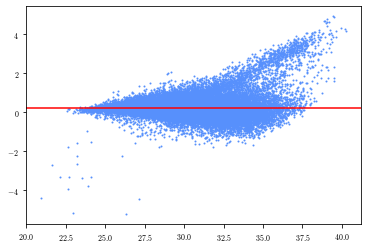

In [20]:
plt.scatter(catalog.u, du_mean, s=1)
plt.axhline(0.20548664, c="r")

In [21]:
du_mean.mean()

0.20550693268045161

In [22]:
du_mean.std()

0.3354858142327289

In [23]:
du_mean[catalog.u < 30].std()

0.16087008043745463

In [24]:
du_mean[catalog.u < 30].mean()

0.20018315857457497

In [25]:
du_mean[catalog.u < 30].std() * np.sqrt(np.sum(catalog.u < 30))

44.695545150863985

In [26]:
0.205 / 45

0.004555555555555555

In [27]:
1 / (0.205 / 45)

219.51219512195127

In [28]:
means = du_mean[catalog.u < 30]

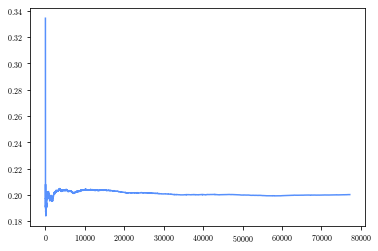

In [29]:
m = [means[:i].mean() for i in range(len(means))]
plt.plot(range(len(means)), m)
    

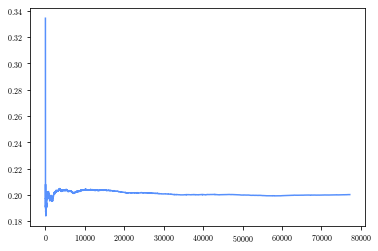

In [30]:
plt.plot(range(len(means)), m)

(0.18, 0.22)

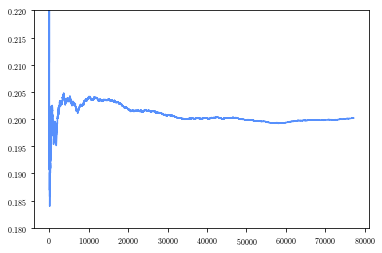

In [31]:
plt.plot(range(len(means)), m)
plt.ylim(0.18, 0.22)

(0.19, 0.21)

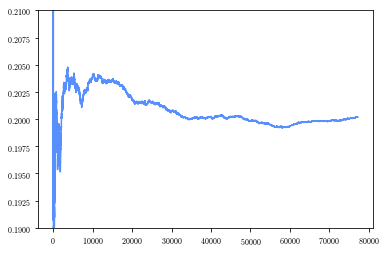

In [32]:
plt.plot(range(len(means)), m)
plt.ylim(0.19, 0.21)

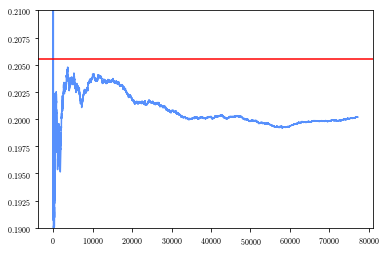

In [33]:
plt.plot(range(len(means)), m)
plt.ylim(0.19, 0.21)
plt.axhline(0.20548664, c="r")

In [34]:
plt.plot(range(len(means)), m - .20548664)

TypeError: unsupported operand type(s) for -: 'list' and 'float'

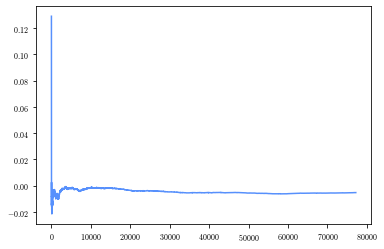

In [35]:
plt.plot(range(len(means)), np.array(m) - 0.20548664)

(-0.01, 0.01)

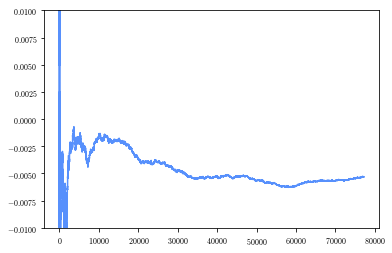

In [36]:
plt.plot(range(len(means)), np.array(m) - 0.20548664)
plt.ylim(-0.01, 0.01)

(-0.01, 0.01)

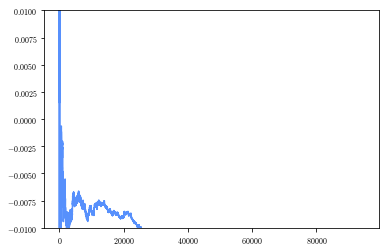

In [37]:
means = du_mean[catalog.u < 32]
m = np.array([means[:i].mean() for i in range(len(means))])
plt.plot(range(len(means)), m - 0.20548664)
plt.ylim(-0.01, 0.01)

In [38]:
catalog.u.mean()

29.12962107697901

In [39]:
catalog.query("u < 30").u.mean()

27.834059568341548

In [40]:
catalog.u.mean() - catalog.query("u < 30").u.mean()

1.2955615086374621

(-0.01, 0.01)

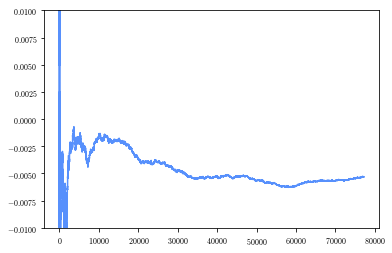

In [41]:
means = du_mean[catalog.u < 30]
m = np.array([means[:i].mean() for i in range(len(means))])
plt.plot(range(len(means)), m - 0.20548664)
plt.ylim(-0.01, 0.01)

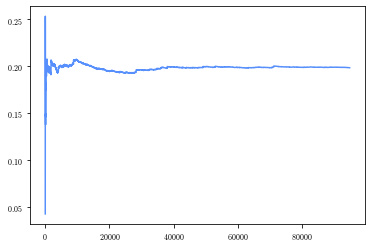

In [42]:
means = du_mean[catalog.u < 32]
s = np.array([means[:i].std() for i in range(len(means))])
plt.plot(range(len(means)), s)
#plt.ylim(-0.01, 0.01)

In [43]:
means.std()

0.19822640796221436

In [44]:
means.std() / np.sqrt(len(means))

0.0006438298179971896

In [45]:
means.mean()

0.19262362471816719

In [46]:
means.mean() - 0.20548664

-0.012863015281832813

In [47]:
(means.mean() - 0.20548664) / (means.std() / np.sqrt(len(means)))

-19.978905795085375

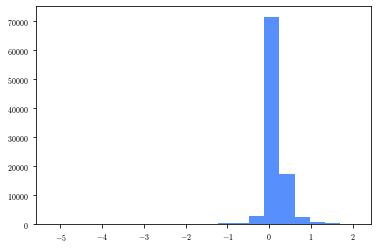

In [48]:
plt.hist(means, bins=20);

In [49]:
len(means)

94794

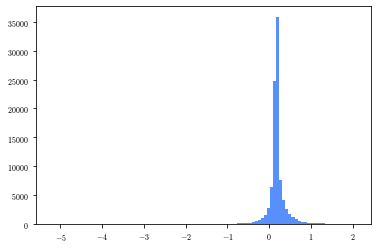

In [50]:
plt.hist(means, bins=100);

In [51]:
means[(means > -1) & (means < 2)]

16        0.274835
20        0.334391
31        0.198460
35        0.222102
51        0.056381
            ...   
673898    0.180813
673903    0.137379
673905    0.247676
673909   -0.089293
673919    0.096746
Name: u, Length: 94683, dtype: float64

In [52]:
means[(means > -1) & (means < 2)].mean()

0.1946047324836547

In [53]:
means[(means > -1)].mean()

0.19462448595977858

In [54]:
means[(means > 0)].mean()

0.22230595974920023

In [55]:
means.mean()

0.19262362471816719

In [56]:
means = du_mean[catalog.u < 30]

In [57]:
means.mean()

0.20018315857457497

In [58]:
means[(means > -1) & (means < 2)].mean()

0.2016313903075173

In [59]:
cm = means[(means > -1) & (means < 2)]

In [60]:
cm.mean()

0.2016313903075173

In [61]:
cm.std()

0.14808032207641933

In [62]:
cm.std() / np.sqrt(cm.size)

0.0005331737915362357

In [63]:
(cm.mean() - 0.20548664) / (cm.std() / np.sqrt(len(cm)))

-7.230756188098709

In [64]:
#z_samples, u_samples = sample_with_errors(catalog, ensemble, seed=0)

In [65]:
u_samples.shape

(110723, 100)

In [66]:
catalog.u.shape

(110723,)

In [67]:
catalog.u -  u_samples

ValueError: operands could not be broadcast together with shapes (110723,) (110723,100) 

In [68]:
catalog.u.to_numpy()[:, None] -  u_samples

array([[ 2.57285131e-01, -1.64126079e-03, -5.89570872e-02, ...,
        -1.17455470e-01,  5.84597600e-01,  3.76521123e-01],
       [ 3.76315923e-01,  3.53172155e-01, -9.95255990e-02, ...,
         3.40654226e-01,  2.98181386e-01, -9.56327005e-02],
       [ 4.10694313e-01,  3.22048378e-01,  3.57196999e-01, ...,
         1.91797447e-01,  2.58011055e-01,  3.97482109e-01],
       ...,
       [-4.92446947e-01,  6.57484007e-01, -3.31485796e-01, ...,
        -5.23323106e-01, -1.12171646e-02,  3.62604094e-01],
       [-9.78984508e-01, -6.09565410e-01, -4.80659160e-01, ...,
        -1.27555433e+00, -2.18473783e+00, -1.09362761e+00],
       [-1.50567005e-02,  4.25714402e-01,  8.55203538e-01, ...,
         3.97823243e-01,  2.36642747e-01, -1.83754871e-02]])

In [69]:
du_samples = catalog.u.to_numpy()[:, None] -  u_samples
du_samples.mean()

0.2118813105079716

In [70]:
U_samples = u_samples.copy()
U_samples[U_samples > 30] = np.nan 
du_samples = catalog.u.to_numpy()[:, None] -  U_samples
du_means = np.nanmean(du_samples, axis=1)

<ipython-input-70-9c8768341bc0>:4: RuntimeWarning: Mean of empty slice
  du_means = np.nanmean(du_samples, axis=1)


In [71]:
du_means.mean()

nan

In [72]:
np.nanmean(du_means.mean())

<ipython-input-72-89f393f887c6>:1: RuntimeWarning: Mean of empty slice
  np.nanmean(du_means.mean())


nan

In [73]:
np.nanmean(du_means)

0.5941674795751597

In [74]:
du_samples = catalog.u.to_numpy()[:, None] -  u_samples
du_samples.mean()

0.2118813105079716

In [75]:
means = []
for i in range(10):
    z_samples, u_samples = sample_with_errors(catalog, ensemble, seed=0)
    du_samples = catalog.u.to_numpy()[:, None] -  u_samples
    means.append(du_samples.mean())

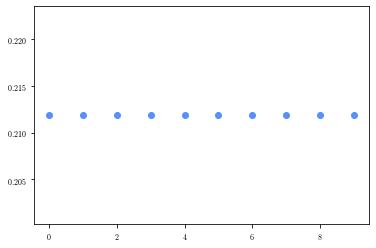

In [76]:
plt.scatter(range(len(means)), means)

In [77]:
means = []
for i in range(10):
    z_samples, u_samples = sample_with_errors(catalog, ensemble, seed=i)
    du_samples = catalog.u.to_numpy()[:, None] -  u_samples
    means.append(du_samples.mean())

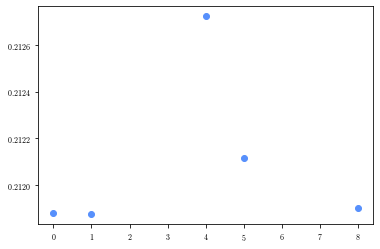

In [78]:
plt.scatter(range(len(means)), means)

In [79]:
np.mean(means)

nan

In [80]:
means

[0.2118813105079716,
 0.21187756340347025,
 nan,
 nan,
 0.21272186718471187,
 0.21211631561871366,
 nan,
 nan,
 0.2119024227723505,
 nan]

In [81]:
means = []
for i in range(10):
    z_samples, u_samples = sample_with_errors(catalog, ensemble, seed=i)
    du_samples = catalog.u.to_numpy()[:, None] -  u_samples
    du_means = np.nanmean(du_samples, axis=1)
    means.append(np.nanmean(du_means))

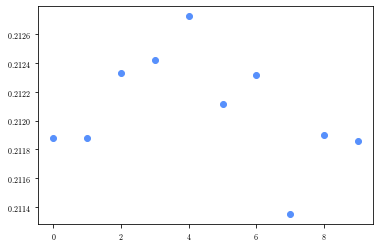

In [82]:
plt.scatter(range(len(means)), means)

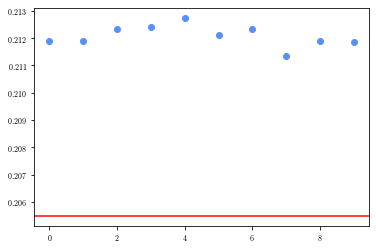

In [83]:
plt.scatter(range(len(means)), means)
plt.axhline(0.20548664, c="r")

In [84]:
np.std(means)

0.00036501663194297366

In [85]:
np.mean(means)

0.21207678978479017

In [86]:
(np.mean(means) - 0.20548664) / np.std(means)

18.054382206396948

In [87]:
means = []
for i in range(10):
    z_samples, u_samples = sample_with_errors(catalog, ensemble, seed=i)
    u_samples[z_samples < 2.36] = np.nan
    du_samples = catalog.u.to_numpy()[:, None] -  u_samples
    du_means = np.nanmean(du_samples, axis=1)
    means.append(np.nanmean(du_means))

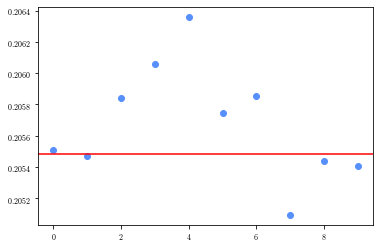

In [88]:
plt.scatter(range(len(means)), means)
plt.axhline(0.20548664, c="r")

In [89]:
(np.mean(means) - 0.20548664) / np.std(means)

0.5470480959836194

In [90]:
means = []
for i in range(10):
    z_samples, u_samples = sample_with_errors(catalog, ensemble, seed=i)
    u_samples[z_samples < 2.36] = np.nan
    du_samples = catalog.u.to_numpy()[:, None] -  u_samples
    du_means = np.nanmean(du_samples, axis=1)
    means.append(du_means)

In [91]:
means = np.array(means)

In [92]:
means.shape

(10, 110723)

In [93]:
catalog.shape

(110723, 21)

In [94]:
m =[]
s = []
for n in range(len(catalog)):
    ms = np.nanmean(means[:, :n], axis=1)
    m.append(np.nanmean(ms))
    m.append(np.nanstd(ms))

<ipython-input-94-ca92cdcf506f>:4: RuntimeWarning: Mean of empty slice
  ms = np.nanmean(means[:, :n], axis=1)
<ipython-input-94-ca92cdcf506f>:5: RuntimeWarning: Mean of empty slice
  m.append(np.nanmean(ms))
/astro/store/epyc/users/jfc20/local/mambaforge/envs/rubin-lya/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


KeyboardInterrupt: 

In [95]:
m =[]
s = []
for n in range(1, len(catalog)):
    ms = np.nanmean(means[:, :n], axis=1)
    m.append(np.nanmean(ms))
    m.append(np.nanstd(ms))

In [96]:
m = np.array(m)
s = np.array(s)

ValueError: x and y must have same first dimension, but have shapes (110722,) and (221444,)

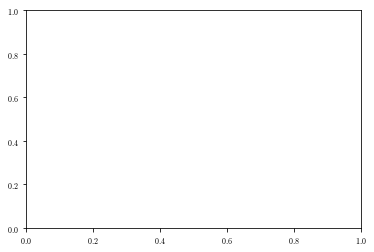

In [97]:
x = range(1, len(catalog))
plt.plot(x, m, c="C0")
plt.fill_between(x, m-s, m+s, alpha=0.5, c="C0")
plt.axhline(0.20548664, c="r")

In [98]:
len(m)

221444

In [99]:
len(catalog)

110723

In [100]:
ms.shape

(10,)

In [101]:
ms

array([0.20550791, 0.20546802, 0.20584434, 0.20605772, 0.20635829,
       0.20575037, 0.20585248, 0.20509581, 0.20543952, 0.20540707])

In [102]:
means.shape

(10, 110723)

In [103]:
means[:, :1]

array([[0.17478853],
       [0.19934636],
       [0.21968404],
       [0.25621896],
       [0.20661815],
       [0.21849765],
       [0.19071885],
       [0.18058439],
       [0.14134378],
       [0.14520681]])

In [104]:
means[:, :5]

array([[ 0.17478853,  0.27483346,  0.33439083, -0.52454768,  0.19846323],
       [ 0.19934636,  0.23586671,  0.32887882, -0.58900419,  0.12545004],
       [ 0.21968404,  0.1230313 ,  0.32463503, -0.57654426,  0.20786934],
       [ 0.25621896,  0.27180502,  0.29366577, -0.5897765 ,  0.19972513],
       [ 0.20661815,  0.23552521,  0.34941278, -0.4918521 ,  0.17886045],
       [ 0.21849765,  0.25544726,  0.3471863 , -0.48348225,  0.19265335],
       [ 0.19071885,  0.29332511,  0.32981726, -0.43285854,  0.1987743 ],
       [ 0.18058439,  0.28307729,  0.34751274, -0.43789511,  0.20045095],
       [ 0.14134378,  0.25331315,  0.35132082, -0.36400104,  0.19933226],
       [ 0.14520681,  0.23229853,  0.3347226 , -0.46142513,  0.12822592]])

In [105]:
np.nanmean(means[:, :5], axis=1)

array([0.09158567, 0.06010755, 0.05973509, 0.08632768, 0.0957129 ,
       0.10606046, 0.11595539, 0.11474605, 0.11626179, 0.07580574])

In [106]:
np.nanmean(np.nanmean(means[:, :5], axis=1))

0.09222983330893901

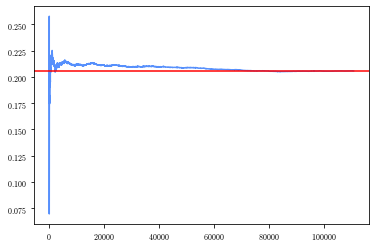

In [107]:
x = range(1, len(catalog))
plt.plot(x, m[::2], c="C0")
#plt.fill_between(x, m-s, m+s, alpha=0.5, c="C0")
plt.axhline(0.20548664, c="r")

ValueError: operands could not be broadcast together with shapes (110722,) (0,) 

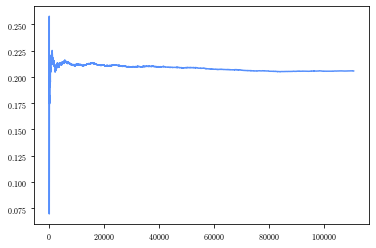

In [108]:
x = range(1, len(catalog))
plt.plot(x, m[::2], c="C0")
plt.fill_between(x, m[::2]-s[::2], m[::2]+s[::2], alpha=0.5, c="C0")
plt.axhline(0.20548664, c="r")

ValueError: operands could not be broadcast together with shapes (110722,) (0,) 

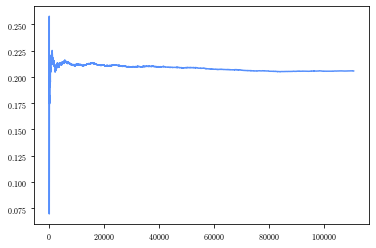

In [109]:
x = range(1, len(catalog))
plt.plot(x, m[::2], c="C0")
plt.fill_between(x, m[::2]-s[1::2], m[::2]+s[1::2], alpha=0.5, c="C0")
plt.axhline(0.20548664, c="r")

In [110]:
m[::2]-s[1::2]

ValueError: operands could not be broadcast together with shapes (110722,) (0,) 

In [111]:
m[::2]-m[1::2]

array([0.16009353, 0.19362512, 0.2414584 , ..., 0.20533959, 0.20533749,
       0.20532993])

AttributeError: 'PolyCollection' object has no property 'c'

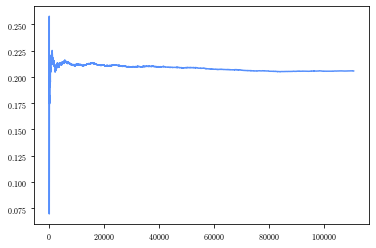

In [112]:
x = range(1, len(catalog))
plt.plot(x, m[::2], c="C0")
plt.fill_between(x, m[::2]-m[1::2], m[::2]+m[1::2], alpha=0.5, c="C0")
plt.axhline(0.20548664, c="r")

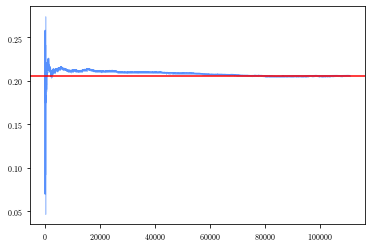

In [113]:
x = range(1, len(catalog))
plt.plot(x, m[::2], c="C0")
plt.fill_between(x, m[::2]-m[1::2], m[::2]+m[1::2], alpha=0.5, color="C0")
plt.axhline(0.20548664, c="r")

(0.2, 0.25)

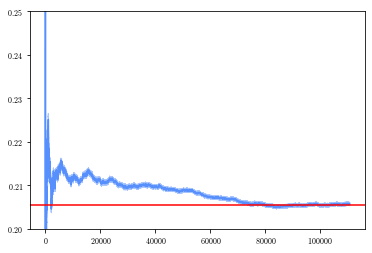

In [114]:
x = range(1, len(catalog))
plt.plot(x, m[::2], c="C0")
plt.fill_between(x, m[::2]-m[1::2], m[::2]+m[1::2], alpha=0.5, color="C0")
plt.axhline(0.20548664, c="r")
plt.ylim(0.2, 0.25)

(0.204, 0.215)

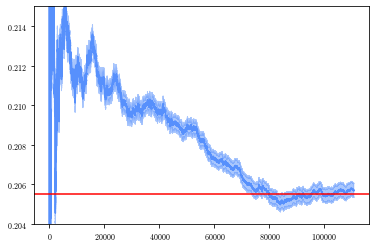

In [115]:
x = range(1, len(catalog))
plt.plot(x, m[::2], c="C0")
plt.fill_between(x, m[::2]-m[1::2], m[::2]+m[1::2], alpha=0.5, color="C0")
plt.axhline(0.20548664, c="r")
plt.ylim(0.204, 0.215)

In [116]:
means = []
for i in range(20):
    z_samples, u_samples = sample_with_errors(catalog, ensemble, seed=i)
    u_samples[z_samples < 2.36] = np.nan
    du_samples = catalog.u.to_numpy()[:, None] -  u_samples
    du_means = np.nanmean(du_samples, axis=1)
    means.append(du_means)

In [117]:
m =[]
s = []
for n in range(1, len(catalog), 100):
    ms = np.nanmean(means[:, :n], axis=1)
    m.append(np.nanmean(ms))
    s.append(np.nanstd(ms))

m = np.array(m)
s = np.array(s)

TypeError: list indices must be integers or slices, not tuple

ValueError: x and y must have same first dimension, but have shapes (1108,) and (0,)

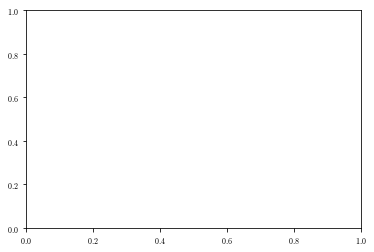

In [118]:
x = range(1, len(catalog), 100)
plt.plot(x, m, c="C0")
plt.fill_between(x, m-s, m+s, alpha=0.25, color="C0")
plt.axhline(0.20548664, c="r")
plt.ylim(0.204, 0.215)

In [119]:
for i in range(1, 20, 2):
    print(i)

1
3
5
7
9
11
13
15
17
19


In [120]:
means = np.array(means)

In [121]:
m =[]
s = []
for n in range(1, len(catalog), 100):
    ms = np.nanmean(means[:, :n], axis=1)
    m.append(np.nanmean(ms))
    s.append(np.nanstd(ms))

m = np.array(m)
s = np.array(s)

(0.204, 0.215)

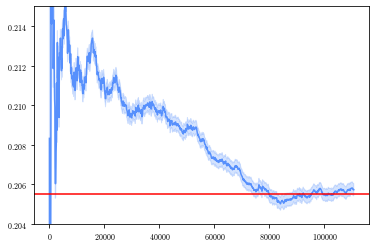

In [122]:
x = range(1, len(catalog), 100)
plt.plot(x, m, c="C0")
plt.fill_between(x, m-s, m+s, alpha=0.25, color="C0")
plt.axhline(0.20548664, c="r")
plt.ylim(0.204, 0.215)

In [123]:
s[-1]

0.0003088376911964763

In [124]:
m[-1]

0.2057221779969586

In [125]:
0.20548664 - m[-1]

-0.0002355379969586069

In [126]:
s[-1] * np.sqrt(len(catalog))

0.10276594477546436

(0.204, 0.215)

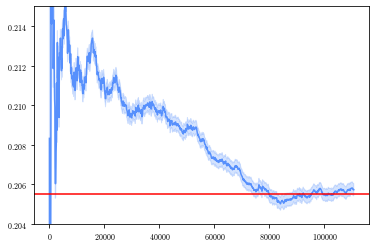

In [127]:
x = np.arange(1, len(catalog), 100)
plt.plot(x, m, c="C0")
plt.fill_between(x, m-s, m+s, alpha=0.25, color="C0")
plt.axhline(0.20548664, c="r")
plt.ylim(0.204, 0.215)

In [128]:
s2 = 0.10276594477546436 / np.sqrt(x)

(0.204, 0.215)

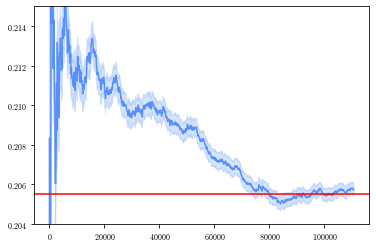

In [129]:
x = np.arange(1, len(catalog), 100)
plt.plot(x, m, c="C0")
plt.fill_between(x, m-s2, m+s2, alpha=0.25, color="C0")
plt.axhline(0.20548664, c="r")
plt.ylim(0.204, 0.215)

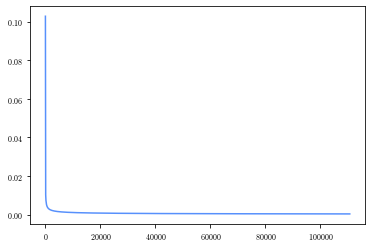

In [130]:
plt.plot(x, s2)

ValueError: x and y must be the same size

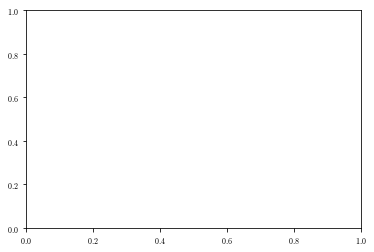

In [131]:
plt.scatter(range(len(means)), means)

In [132]:
means

array([[ 0.17478853,  0.27483346,  0.33439083, ..., -0.08929187,
        -0.63125038,  0.0967474 ],
       [ 0.19934636,  0.23586671,  0.32887882, ..., -0.01448722,
        -0.644802  ,  0.17257745],
       [ 0.21968404,  0.1230313 ,  0.32463503, ...,  0.01221023,
        -0.68998739,  0.02462644],
       ...,
       [ 0.26758928,  0.2235687 ,  0.34331348, ...,  0.00756316,
        -0.54040888,  0.14339469],
       [ 0.24509534,  0.1963616 ,  0.34238945, ...,  0.02732665,
        -0.70600161,  0.28828763],
       [ 0.22491666,  0.29263958,  0.3524283 , ..., -0.04566136,
        -0.69352798,  0.14165461]])

In [133]:
ms

array([0.2055298 , 0.20548527, 0.2058624 , 0.20607725, 0.20637697,
       0.20576988, 0.20587237, 0.2051144 , 0.20545824, 0.20542863,
       0.20608394, 0.20589164, 0.20561753, 0.20568955, 0.20604463,
       0.20542448, 0.20578899, 0.20602762, 0.2056497 , 0.20525025])

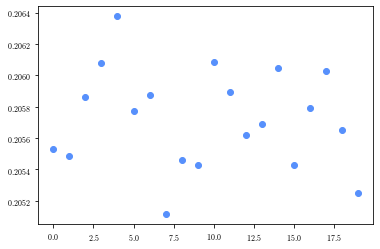

In [134]:
plt.scatter(range(len(means)), ms)

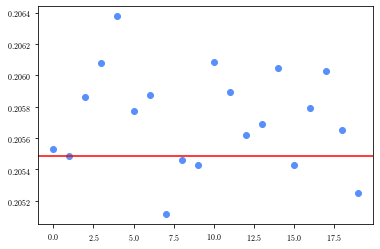

In [135]:
plt.scatter(range(len(means)), ms)
plt.axhline(0.20548664, c="r")

In [136]:
means.shape

(20, 110723)

ValueError: x and y must be the same size

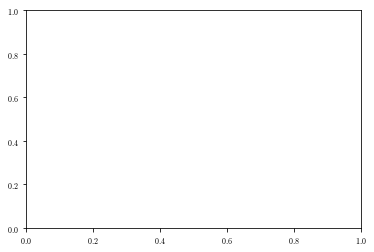

In [137]:
plt.scatter(range(len(means)), means[0])

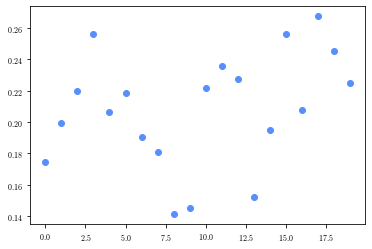

In [138]:
plt.scatter(range(len(means)), means[:, 0])

In [139]:
u_samples

array([[32.72239 , 32.964714, 32.645676, ..., 32.920395, 33.006367,
        32.89964 ],
       [31.114536, 31.533903, 31.472391, ..., 31.461647, 31.261915,
        31.241837],
       [27.17804 , 27.280277, 27.341051, ..., 27.29278 , 27.436539,
        27.319868],
       ...,
       [27.35188 , 26.67349 , 27.281118, ..., 26.529728, 26.603535,
        27.159416],
       [31.881767, 34.196327, 34.20231 , ..., 31.800835, 32.904793,
        33.684753],
       [31.325792, 31.211178, 31.458231, ..., 30.81563 , 31.354004,
        30.952332]], dtype=float32)

In [140]:
UU = np.nanmean(u_samples, axis=1)

In [141]:
u_samples.shape

(110723, 100)

In [142]:
UU += 0.20548664

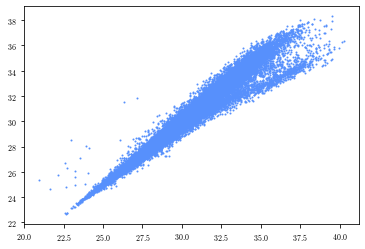

In [143]:
plt.scatter(catalog.u, UU, s=1)

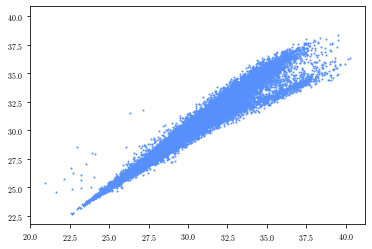

In [144]:
plt.scatter(catalog.u, UU, s=1)
plt.plot([22, 22], [40, 40], c="C2")

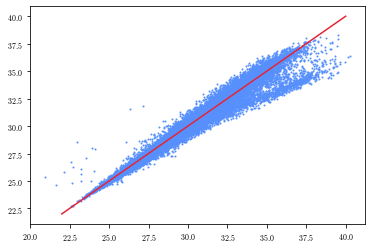

In [145]:
plt.scatter(catalog.u, UU, s=1)
plt.plot([22, 40], [22, 40], c="C2")

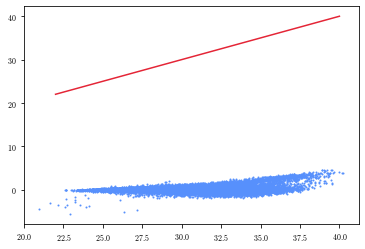

In [146]:
plt.scatter(catalog.u, catalog.u - UU, s=1)
plt.plot([22, 40], [22, 40], c="C2")

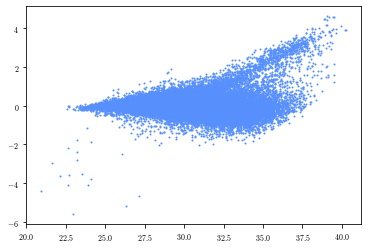

In [147]:
plt.scatter(catalog.u, catalog.u - UU, s=1)
#plt.plot([22, 40], [22, 40], c="C2")

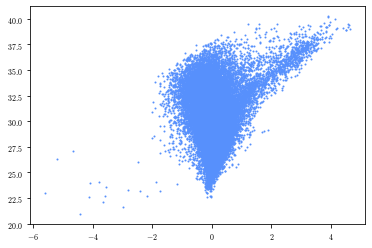

In [148]:
plt.scatter(catalog.u - UU, catalog.u, s=1)


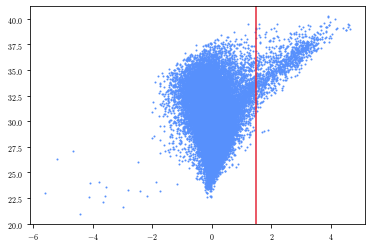

In [149]:
plt.scatter(catalog.u - UU, catalog.u, s=1)
plt.axvline(1.5, c="C2")

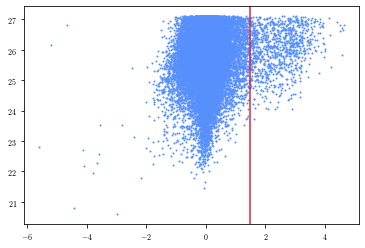

In [150]:
plt.scatter(catalog.u - UU, catalog.i, s=1)
plt.axvline(1.5, c="C2")

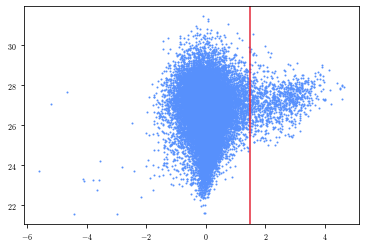

In [151]:
plt.scatter(catalog.u - UU, catalog.g, s=1)
plt.axvline(1.5, c="C2")

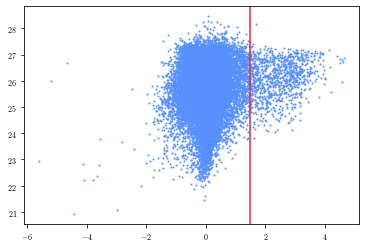

In [152]:
plt.scatter(catalog.u - UU, catalog.r, s=1)
plt.axvline(1.5, c="C2")

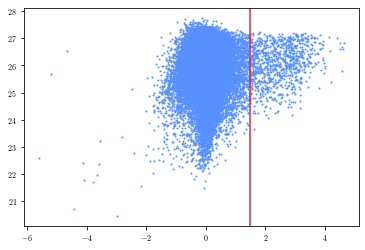

In [153]:
plt.scatter(catalog.u - UU, catalog.z, s=1)
plt.axvline(1.5, c="C2")

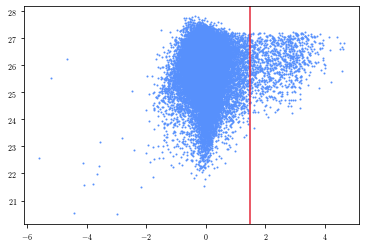

In [154]:
plt.scatter(catalog.u - UU, catalog.y, s=1)
plt.axvline(1.5, c="C2")

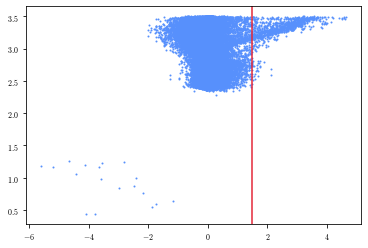

In [155]:
plt.scatter(catalog.u - UU, catalog.redshift, s=1)
plt.axvline(1.5, c="C2")

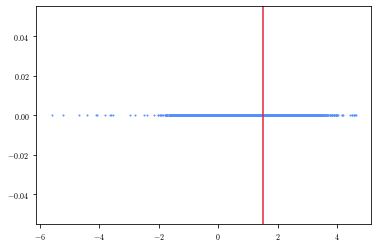

In [157]:
plt.scatter(catalog.u - UU, catalog.u - catalog.u, s=1)
plt.axvline(1.5, c="C2")

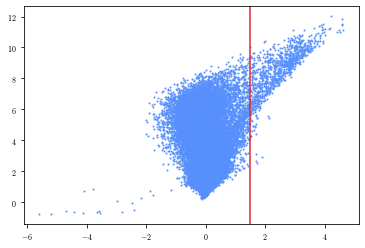

In [158]:
plt.scatter(catalog.u - UU, catalog.u - catalog.g, s=1)
plt.axvline(1.5, c="C2")

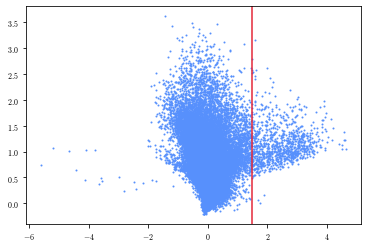

In [159]:
plt.scatter(catalog.u - UU, catalog.g - catalog.r, s=1)
plt.axvline(1.5, c="C2")

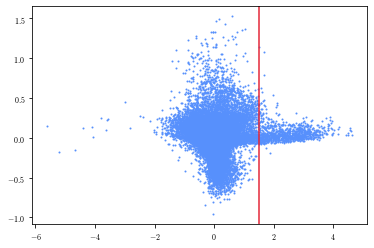

In [160]:
plt.scatter(catalog.u - UU, catalog.r - catalog.i, s=1)
plt.axvline(1.5, c="C2")

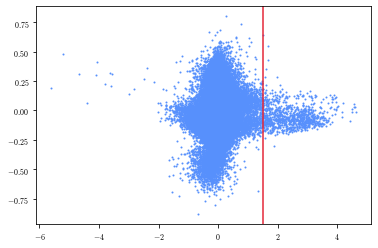

In [161]:
plt.scatter(catalog.u - UU, catalog.i - catalog.z, s=1)
plt.axvline(1.5, c="C2")

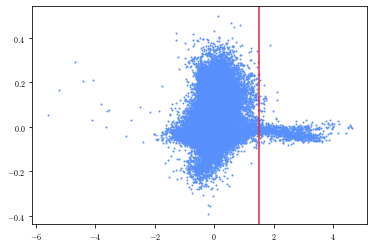

In [162]:
plt.scatter(catalog.u - UU, catalog.z - catalog.y, s=1)
plt.axvline(1.5, c="C2")

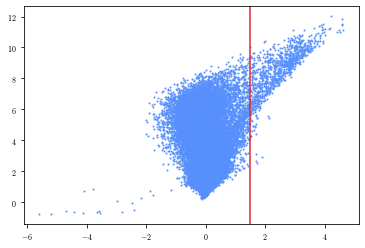

In [163]:
plt.scatter(catalog.u - UU, catalog.u - catalog.g, s=1)
plt.axvline(1.5, c="C2")

In [164]:
p = catalog.u - UU

In [165]:
p = (catalog.u - UU).copy()
p = p[p<1.5]
p = p[catalog.redshift > 2.36]

In [166]:
p.mean()

-0.02080399437215391

In [167]:
p = (catalog.u - UU).copy()
print(np.nanmean(p))

#p = p[p<1.5]
#p = p[catalog.redshift > 2.36]

-0.0002562043942705287


In [168]:
p = (catalog.u - np.nanmean(u_samples, axis=1)).copy()
print(np.nanmean(p))

#p = p[p<1.5]
#p = p[catalog.redshift > 2.36]

0.20523010671857772


In [169]:
p = (catalog.u - np.nanmean(u_samples, axis=1)).copy()
print(np.nanmean(p))

p[catalog.redshift < 2.36] = np.nan 
print(np.nanmean(p))
#p = p[p<1.5]
#p = p[catalog.redshift > 2.36]

0.20523010671857772
0.20572751739866457


In [170]:
p = (catalog.u - np.nanmean(u_samples, axis=1)).copy()
print(np.nanmean(p))

p[catalog.redshift < 2.36] = np.nan 
print(np.nanmean(p))

p[p>1.5] = np.nan
print(np.nanmean(p))

0.20523010671857772
0.20572751739866457
0.18215431972915036


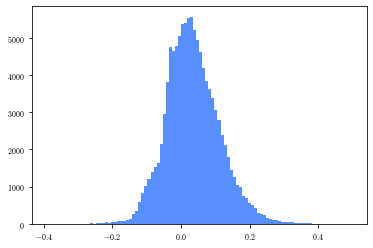

In [171]:
plt.hist(catalog.z - catalog.y, bins=100);